# 파이프라인 E2E 지연·품질 병목 측정 — 시각화 노트북

- 본문 텍스트·표는 `2026-09-03_pipeline_latency_quality_report.md`를 **그대로** 옮겼다. 절마다 뒤에 붙은 코드 셀이 `latency/`의 원 데이터(analysis_summary.json · per_run_eval.jsonl · traces_full.jsonl · roadmap.json)에서 같은 수치를 다시 계산해 막대그래프·표로 보인다.
- 그래프 값은 실측이며, 로드맵(§5.2-3)만 (추정)이다. 보고서 숫자와 그래프 숫자가 다르면 그래프 쪽이 데이터 파일의 현재 값이다.
- 실행: 노트북 폴더(`test/pipline-test/`) 또는 repo 루트에서 열면 `latency/`를 자동으로 찾는다. 필요 패키지 pandas · matplotlib (mirea 환경에는 matplotlib이 없어 `pip install matplotlib`가 필요하다).
- 원인 코드 범례: **A** 그래프 데이터 부재 · **B** 벡터 검색 실패 · **C** RDB(SQL 생성·필터) · **D** 계획·라우팅 · **E** 생성 · **F** 인프라(예외·429).

In [ ]:
# 데이터 로드 · 한글 폰트 · 공용 팔레트
import json, math, statistics
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 48)

# 노트북 위치(test/pipline-test/) 또는 repo 루트 어디에서 열어도 latency/ 를 찾는다
_cands = [Path.cwd() / "latency", Path.cwd() / "test/pipline-test/latency",
          Path.cwd().parent / "latency"]
LAT = next((p for p in _cands if (p / "analysis_summary.json").exists()), None)
assert LAT is not None, f"latency/ 디렉터리를 찾지 못했습니다: {[str(p) for p in _cands]}"

# 한글 폰트: 설치 폰트 → Windows 폰트 파일(WSL 포함) 순서로 시도
def _set_korean_font():
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic", "Noto Sans CJK KR"]:
        if name in installed:
            matplotlib.rcParams["font.family"] = name
            return name
    for fp in ["C:/Windows/Fonts/malgun.ttf", "/mnt/c/Windows/Fonts/malgun.ttf",
               "C:/Windows/Fonts/NanumGothic.ttf", "/mnt/c/Windows/Fonts/NanumGothic.ttf"]:
        if Path(fp).exists():
            fm.fontManager.addfont(fp)
            name = fm.FontProperties(fname=fp).get_name()
            matplotlib.rcParams["font.family"] = name
            return name
    return "(한글 폰트 없음: 라벨이 □로 보일 수 있음)"

FONT = _set_korean_font()
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

def pct(values, q):
    """nearest-rank 백분위(analyze.py와 동일). n=3이면 p95는 최댓값."""
    vals = sorted(v for v in values if v is not None)
    if not vals:
        return None
    return vals[max(0, math.ceil(q * len(vals)) - 1)]

# --- 원본 산출물 ---
S = json.load(open(LAT / "analysis_summary.json", encoding="utf-8"))
ROAD = json.load(open(LAT / "roadmap.json", encoding="utf-8"))
Q = pd.DataFrame(S["questions"]).set_index("id")
runs = pd.DataFrame([json.loads(l) for l in open(LAT / "per_run_eval.jsonl", encoding="utf-8")])
traces = [json.loads(l) for l in open(LAT / "traces_full.jsonl", encoding="utf-8")]
traces = [t for t in traces if not t.get("superseded")]  # 429로 새 창에서 재실행된 회차는 대체본만 사용

runs = runs.merge(Q[["type", "route"]], left_on="question_id", right_index=True, how="left")
runs["qnum"] = runs["question_id"].str[1:].astype(int)
warm = runs[runs["round"] >= 2]
scored = warm[warm["status"].isin(["ok", "exception"])]          # 429(rate_limited) 회차는 분모 제외
wrong = scored[~scored["overall_pass"].astype(bool)]

TYPE_ORDER = ["산출가능", "부분산출", "외부데이터필요", "정의변경", "ABSTAIN"]
CAUSE_ORDER = ["A", "B", "C", "D", "E", "F"]
CAUSE_LABEL = {"A": "A 그래프 데이터 부재", "B": "B 벡터 검색 실패", "C": "C RDB(SQL 생성·필터)",
               "D": "D 계획·라우팅", "E": "E 생성(답변)", "F": "F 인프라(예외·429)"}
CAUSE_COLOR = {"A": "#7f7f7f", "B": "#bcbd22", "C": "#d62728", "D": "#ff7f0e", "E": "#9467bd", "F": "#1f77b4"}
STAGE_COLOR = {"frame": "#4c72b0", "rdb": "#dd8452", "graph": "#55a868", "vector": "#c44e52", "generate": "#8172b3"}
STAGE_LABEL = {"frame": "query_frame(analyze+verify)", "rdb": "rdb_exec", "graph": "graph_exec",
               "vector": "vector_exec", "generate": "generate"}
TARGET_MS = 15_000

print(f"데이터 경로: {LAT}")
print(f"폰트: {FONT}")
print(f"trace {len(traces)}회차 (superseded 제외) · 채점 warm 회차 {len(scored)} · 정답 {int(scored['overall_pass'].sum())} · 오답 {len(wrong)}")
assert len(scored) == S["accuracy"]["scored_runs"], "per_run_eval과 analysis_summary의 채점 회차 수가 다릅니다"

데이터 경로: /mnt/c/Users/rladl/Desktop/2026_MIRAE_ASSET_AI-Festival/2026_10th_MIRAE-ASSET_AI-Festival/test/pipline-test/latency
폰트: Malgun Gothic
trace 140회차 (superseded 제외) · 채점 warm 회차 104 · 정답 15 · 오답 89


# 파이프라인 E2E 지연·품질 병목 측정 — 실험 결과서

측정일 2026-09-03 · 설계서 해당 없음(과제 지시문이 설계서를 대신한다) · 재현 방법 §부록 C

## Executive Digest

1. warm(2~4회차) E2E p95는 144.0s, p50은 25.0s다. 목표 15.0s 대비 p95 격차 129.0s, 101회차 중 94회차(34/35문항)가 15s를 넘는다.
2. 우선 개선 계층 1순위는 **GraphDB**다. 시간축 점수 33,598(p95 기여 117,593ms × 질의 비율 0.29)로 RDB 27,333을 앞선다. 원인은 엔티티 해소(resolve_frame_seed)가 관계당 p50 15.1s, p95 60.4s이고 SPARQL 339회 중 145회가 1s를 넘기 때문이다.
3. 시간축 1위(GraphDB)와 품질축 1위(RDB, 오답 89회차 중 52회차 = 0.58)가 다르므로 속도 우선안과 품질 우선안을 §5에 각각 제시한다.
4. LangGraph 파이프라인 디벨롭 필요 여부: **No**. (a) 독립 단계 순차 실행 합은 p95 기준 E2E의 14.0%, (b) 재시도·폴백 시간 9.8%, (c) 계획·라우팅 원인 오답 24.7%로 세 조건 모두 미달이다. 시간은 노드 내부의 LLM 호출(E2E의 68.4%)과 Graph 엔티티 해소 SPARQL 순차 조회에서 쓰인다.
5. 온톨로지 DB 데이터 추가 필요 여부: **No**(원인 A 0/89). VectorDB 데이터 추가 필요 여부: **No**(원인 B 0/89).
6. 전체 정답률은 회차 기준 15/104 = 14.4%, 문항 기준 3회차 모두 정답 3/35 = 8.6%다. 429 회차 8건은 새 창에서 재실행해 분모에서 뺐고, 예외 3회차(답변 길이 초과)는 오답으로 셌다.
7. 하위 목표 Query Frame ≤ 5.0s는 미달이다. p50 9.1s, p95 19.6s, 101/101회차가 5s 초과다.
8. 15초 로드맵(§5-3) 6개 조치를 전부 적용하면 p95 17.6s(추정)로 부족분 2.6s가 남고, 품질 검증이 안 된 verify_intent 제거를 빼면 p95 26.6s로 부족분 11.6s다.

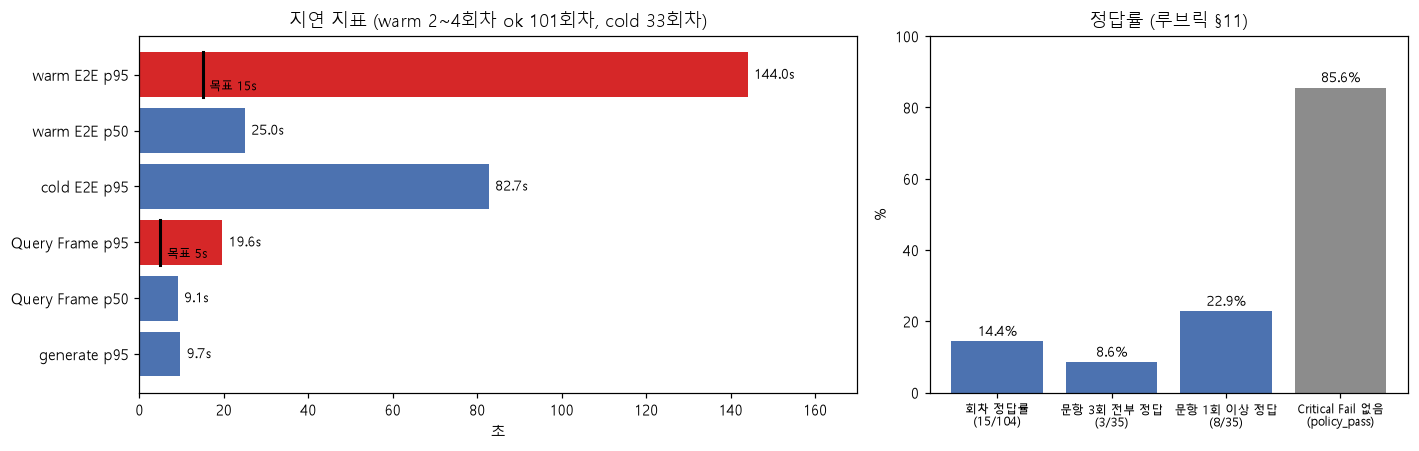

,지표,실측,목표,단위,격차
0,warm E2E p95,144.01,15.0,s,129.01
1,warm E2E p50,25.00,NaN,s,NaN
2,cold E2E p95,82.75,NaN,s,NaN
3,Query Frame p95,19.60,5.0,s,14.60
4,Query Frame p50,9.06,NaN,s,NaN
5,generate p95,9.68,NaN,s,NaN


In [2]:
# ▶ 핵심 지표 시각화
# Digest 핵심 지표 — 실측 vs 목표
w, c, a = S["warm"], S["cold"], S["accuracy"]
kpi = pd.DataFrame([
    ["warm E2E p95", w["e2e_p95"] / 1000, 15.0, "s"],
    ["warm E2E p50", w["e2e_p50"] / 1000, None, "s"],
    ["cold E2E p95", c["e2e_p95"] / 1000, None, "s"],
    ["Query Frame p95", w["frame_p95"] / 1000, 5.0, "s"],
    ["Query Frame p50", w["frame_p50"] / 1000, None, "s"],
    ["generate p95", next(l for l in S["layers"] if l["layer"] == "generate(LLM)")["p95"] / 1000, None, "s"],
], columns=["지표", "실측", "목표", "단위"])
kpi["격차"] = kpi["실측"] - kpi["목표"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [3, 2]})
ax = axes[0]
bars = ax.barh(kpi["지표"], kpi["실측"], color=["#d62728" if (t and v > t) else "#4c72b0" for v, t in zip(kpi["실측"], kpi["목표"])])
for b, v in zip(bars, kpi["실측"]):
    ax.text(b.get_width() + 1.5, b.get_y() + b.get_height() / 2, f"{v:.1f}s", va="center", fontsize=9)
for y, t in enumerate(kpi["목표"]):
    if t:
        ax.plot([t, t], [y - 0.4, y + 0.4], color="black", lw=2)
        ax.text(t + 1.5, y + 0.28, f"목표 {t:.0f}s", fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("초"); ax.set_title("지연 지표 (warm 2~4회차 ok 101회차, cold 33회차)")
ax.set_xlim(0, kpi["실측"].max() * 1.18)

ax = axes[1]
acc = pd.Series({"회차 정답률\n(15/104)": a["pass_runs"] / a["scored_runs"] * 100,
                 "문항 3회 전부 정답\n(3/35)": a["questions_all_pass"] / 35 * 100,
                 "문항 1회 이상 정답\n(8/35)": a["questions_any_pass"] / 35 * 100,
                 "Critical Fail 없음\n(policy_pass)": scored["policy_pass"].astype(bool).mean() * 100})
bars = ax.bar(acc.index, acc.values, color=["#4c72b0", "#4c72b0", "#4c72b0", "#8c8c8c"])
for b, v in zip(bars, acc.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_ylim(0, 100); ax.set_ylabel("%"); ax.set_title("정답률 (루브릭 §11)")
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()
display(kpi.round(2))

## 1. 초요약본

실험 목적 / 문제정의
- 골든셋 35문항의 E2E 응답 시간이 15초 목표를 넘는 원인을 계층(GraphDB / RDB / VectorDB)별로 계측해 우선 개선 계층 하나를 정한다.
- 루브릭(golden_set_data_gap_evaluation_rubric.md) 기준 정답률과 오답 원인 분포를 산출해 속도 개선안이 품질을 해치지 않는지 확인한다.

실험 환경
- HyperCLOVA X HCX-007(thinking effort none, max_tokens 2048), 의도·SQL용 timeout 25s, 답변용 timeout 90s(측정 시작 시 사용자 요청으로 30s에서 변경). bge-m3 1024차원 임베딩.
- RDB: 원격 SQL API(cutoff_date 2026-08-24). GraphDB: 로컬 Oxigraph read-only 스토어 1,169,374 triples(pyoxigraph 0.5.9). VectorDB: 원격 pgvector vec.document_chunk 9,055청크.
- 실행: Windows conda mirea(Python 3.11.15), langgraph·langchain_core 1.6.0·openai 3.5.0. 계측은 test/pipline-test/latency/run_latency.py에서 노드·LLM·SQL·SPARQL·임베딩 호출을 감싸 기록했고 src/는 timeout 한 줄 외에 수정하지 않았다.

실험 설계
1. 35문항 × 4회차(1회차 cold, 2~4회차 warm)를 순차 실행했다. CLOVA 고정창(60 req·60k tok/min) 때문에 문항 간 7초, 토큰 잔량 30k 미만이면 reset 대기, SDK 재시도 0, 429는 새 창에서 1회만 재실행했다.
2. 단계는 query_frame(analyze+verify) → plan/route_guard → graph_exec(내부 tbox_grounding=seed+fragment) → rdb_exec → vector_exec → merge → generate로 나눠 노드 시간과 하위 호출 시간을 남겼다.
3. 채점은 루브릭 §3~§11을 182개 Claim(golden_eval.jsonl)으로 옮긴 결정론 판정 + 1·2회차 전 문항 수동 검토로 보정한 오버라이드(manual_overrides.json) 9건으로 했다. 오답마다 원인 A~F 하나를 붙였다.

실험 결과
- warm E2E p50 25.0s / p95 144.0s / max 188.9s. cold p50 24.8s / p95 82.7s로 cold 페널티는 관측되지 않았다(LLM 호출이 시간을 지배한다).
- 계층 p95 기여: GraphDB 117.6s(질의 10/35), RDB 27.3s(35/35), VectorDB 2.3s(19/35). LLM 단계는 query_frame p95 19.6s, generate p95 9.7s.
- 정답 15/104회차(14.4%). 오답 원인 C(RDB) 52, D(계획·라우팅) 22, E(생성) 12, F(예외) 3, A·B 0.
- 429 발생 8회차(전부 재실행 성공), 답변 길이 초과 예외 3회차(Q11·Q13·Q14, 목록형), Oxigraph transport 폴백 0회.

실험 결론
- 판정: FAIL(15s 목표 미달, 정답률 14.4%).
- 시간축 1순위 GraphDB(엔티티 해소 SPARQL), 품질축 1순위 RDB(SQL 생성 오류). 두 축이 달라 §5-1에 두 시나리오를 둔다.
- 단, 이 판정은 "GraphDB 데이터가 부족하다"를 의미하지 않는다. Graph 원인 오답은 0건이고 느린 것은 이름→URI 해소 방식이다.

후속 조치
- 즉시: Graph 엔티티 해소를 exact-label 인덱스로 교체(A1), SQL 생성기의 코드값 사전·별칭 규칙·폐기 컬럼 차단(품질 우선안).
- 다음 실험: verify_intent 제거와 SQL draft 통합의 정답률 영향을 A/B로 측정한 뒤에만 로드맵에 확정 편입한다.

```text
receive → analyze_intent(LLM 4.7s) → verify_intent(LLM 5.7s) → plan_query(0ms)
   → [wave] graph_search(seed SPARQL ×5~9, p50 14.2s / p95 117.6s) ‖ rdb_search(concept LLM 2.0s + draft 5.5s + write 2.9s + fix 3.0s×재시도, p50 11.4s / p95 27.3s)
   → vector_search(embed 0.23s + pgvector 0.31s, p50 1.2s) → merge(0ms) → generate(LLM p50 2.0s / p95 9.4s)
```

## 2. 실험 환경 상세

| 항목 | 값 |
|---|---|
| 측정일·시각 | 2026-09-03 16:50~18:55 KST(4회차 완료, timeout 90s 조건) |
| 골든셋 | goldset/golden_answers_20260824.csv 35문항(산출가능 14 / 부분산출 10 / ABSTAIN 5 / 외부데이터필요 4 / 정의변경 2) |
| 채점 기준 | test/pipline-test/golden_set_data_gap_evaluation_rubric.md 단일 출처 |
| LLM | HCX-007, temperature 0, thinking none, max_tokens 2048, _llm_plan timeout 25s, _llm_answer timeout 90s |
| SDK 재시도 | 0 (루브릭 §13.2-4, 하네스에서 with_options(max_retries=0)) |
| 데이터 cutoff | 런타임 전 구간 2026-08-24 확인: SQL API /db/version cutoff_date, rdb_schema.DATA_SNAPSHOT_DATE, graph_plan.DATA_CUTOFF, orchestrator snapshot@2026-08-24, kb/manifest.RELEASE_DATE. src/kb/build_rdb.py의 2026-07-11은 로컬 빌드 스크립트로 런타임 경로가 아님 |
| 라우트 배선 | rdb_only / graph_only / graph_then_rdb / vector 모두 graph.py 웨이브 dispatch에 배선. 미배선 라우트 없음 |
| 반복 | 문항당 cold 1회 + warm 3회. p95는 nearest-rank(n=3이면 최댓값) |
| CLOVA 한도 실측 | 요청 60/min과 별도로 토큰 60,000/min이 먼저 소진됨. 호출당 prompt(~4k)+max_tokens(2048)가 예약돼 문항당 약 27k 예약(추정: remaining_tokens 59,993→32,704 관측), 실제 소비 p50 17,104 tok |

## 3. 테스트 목록과 판정

| # | 테스트 | 내용 | 기준 | 실측 | 판정 |
|---|---|---|---|---|---|
| T1 | warm E2E p95 | 35문항 × 3회차 ok 101회차 | ≤ 15.0s | 144.0s | FAIL |
| T2 | warm E2E p50 | 동일 | 참고 | 25.0s | - |
| T3 | Query Frame p95 | analyze+verify | ≤ 5.0s | 19.6s (p50 9.1s, 101/101 초과) | FAIL |
| T4 | cold E2E | 1회차 33 ok | 별도 표기 | p50 24.8s / p95 82.7s | 목표 판정 제외 |
| T5 | 정답률(회차) | 루브릭 §11 PASS | 참고 | 15/104 = 14.4% | - |
| T6 | 정답률(문항, 3회차 전부) | 동일 | 참고 | 3/35 = 8.6% (1회 이상 정답 8/35) | - |
| T7 | 429 | 루브릭 §13 | 분모 분리 | 8회차 재실행, 1회차(Q21 r3) 파이프라인 내부 429로 제외 | 준수 |
| T8 | 단계 합 vs E2E | ±10% | 노드 구간 합집합 | 101/101 회차 ±10% 이내 | PASS |

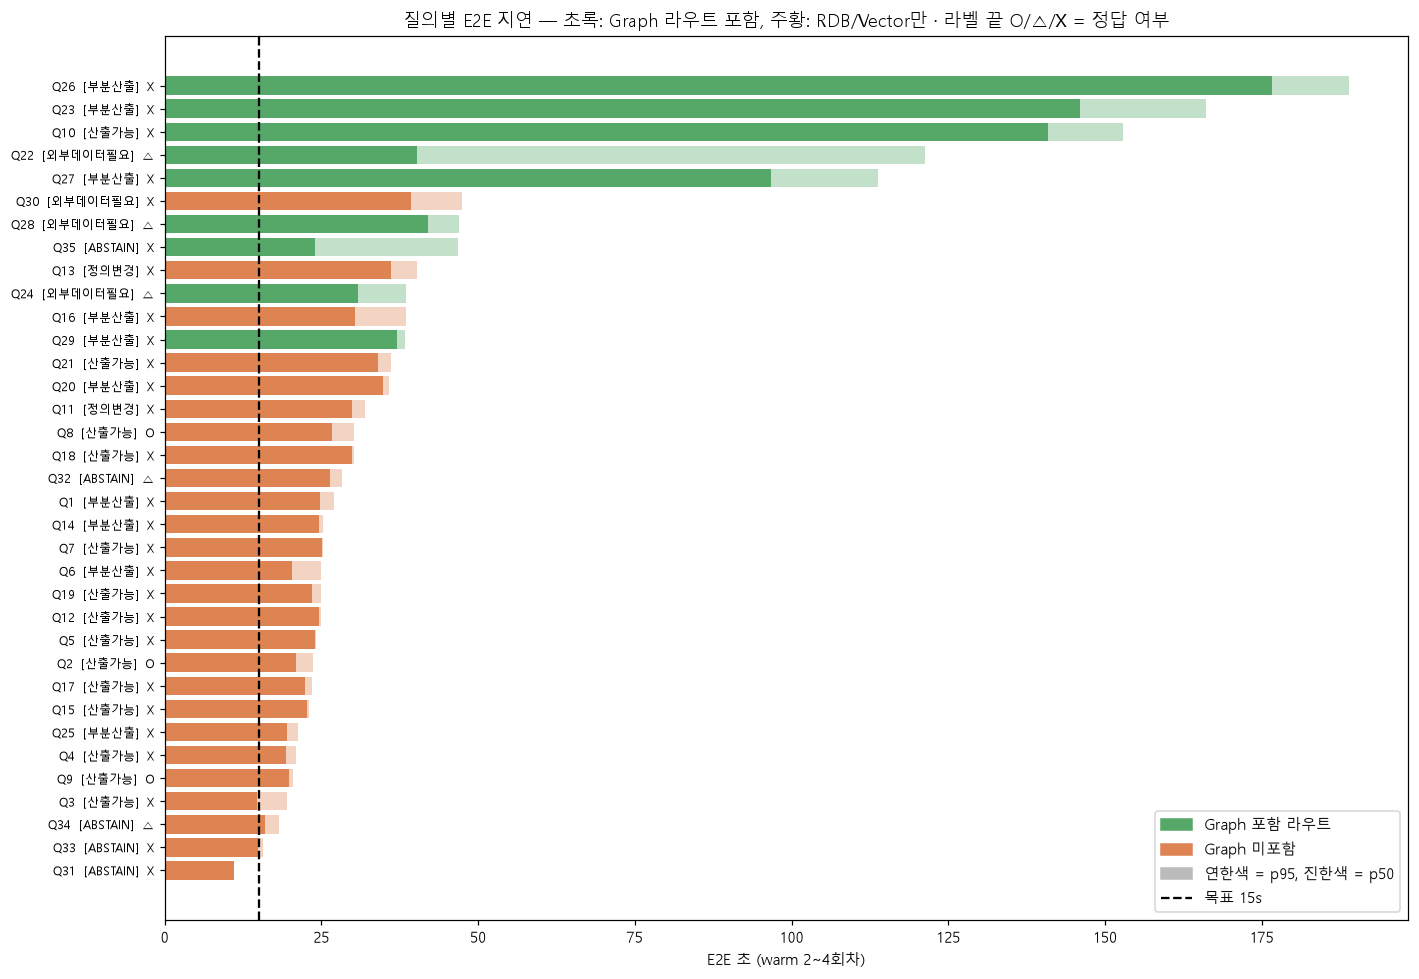

15s 초과 문항(p95 기준): 34/35 · 15s 이내 문항: ['Q31']


In [3]:
# ▶ 질의별 E2E vs 15s
# 질의별 warm E2E p50 / p95 vs 15초 목표 (Graph 포함 여부로 색 구분)
q = Q.sort_values("e2e_p95", ascending=False)
has_graph = q["route"].str.contains("graph")
fig, ax = plt.subplots(figsize=(13, 9))
y = range(len(q))
ax.barh(y, q["e2e_p95"] / 1000, color=["#55a868" if g else "#dd8452" for g in has_graph], alpha=0.35, label="p95(=3회차 최댓값)")
ax.barh(y, q["e2e_p50"] / 1000, color=["#55a868" if g else "#dd8452" for g in has_graph], label="p50")
ax.axvline(TARGET_MS / 1000, color="black", ls="--", lw=1.5, label="목표 15s")
ax.set_yticks(list(y)); ax.set_yticklabels([f"{i}  [{t}]  {'O' if c=='O' else ('△' if c=='△' else 'X')}" for i, t, c in zip(q.index, q["type"], q["correct"])], fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("E2E 초 (warm 2~4회차)")
ax.set_title("질의별 E2E 지연 — 초록: Graph 라우트 포함, 주황: RDB/Vector만 · 라벨 끝 O/△/X = 정답 여부")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#55a868", label="Graph 포함 라우트"), Patch(color="#dd8452", label="Graph 미포함"),
                   Patch(color="#bbbbbb", label="연한색 = p95, 진한색 = p50"),
                   plt.Line2D([], [], color="black", ls="--", label="목표 15s")], loc="lower right")
plt.tight_layout(); plt.show()

over = (Q["e2e_p95"] > TARGET_MS).sum()
print(f"15s 초과 문항(p95 기준): {over}/35 · 15s 이내 문항: {list(Q.index[Q['e2e_p95'] <= TARGET_MS])}")

## 4. 실측 결과 상세

### 4.1 단계별 시간 (warm ok 101회차, ms)

| 단계 | n | p50 | p95 | max | 비고 |
|---|---:|---:|---:|---:|---|
| query_frame(analyze+verify) | 101 | 9,062 | 19,598 | 21,087 | analyze p50 4,033 / p95 8,711, verify p50 5,029 / p95 10,887. verify가 intent를 바꾼 회차 35/101 |
| plan/route_guard | 101 | 1 | 1 | 1 | 규칙 기반, LLM 폴백 0회 |
| graph_exec(노드) | 32 | 14,171 | 117,593 | 122,833 | 관계 체인이 2개 이상이면 노드가 웨이브마다 재호출돼 합산 |
| └ tbox_grounding: resolve_frame_seed | 49 | 15,101 | 60,380 | 64,520 | 관계당 SPARQL 5~9회(최대 40회) 순차 조회 |
| └ tbox_grounding: select_fragment | 25 | 95 | 118 | - | 문제 아님 |
| └ SPARQL 단건 | 339 | 17 | 14,417 | 30,103 | 1s 초과 145회. 정상 plan 실행 SPARQL은 p50 17ms |
| rdb_exec(노드) | 104 | 11,395 | 27,333 | 47,644 | 도메인 단계 p50 11,027 / p95 22,102 |
| └ concept_fallback LLM | 109 | 1,983 | 3,332 | - | 카탈로그 미해결 개념 → LLM. 101회차 중 109회 발생 |
| └ draft LLM | 116 | 5,515 | 8,128 | - | 자연어 초안 |
| └ write_sql LLM | 116 | 2,942 | 4,985 | - | SQL 작성 |
| └ fix_sql LLM | 49 | 2,997 | 5,243 | - | SQL 실패 재시도 49회 |
| └ SQL API | 159 | 89 | 138 | 244 | 문제 아님 |
| vector_exec(노드) | 52 | 1,182 | 2,280 | 3,328 | embed p50 230 / pgvector p50 310 |
| merge | 101 | 0 | 0 | 0 | - |
| generate(LLM) | 104 | 1,957 | 9,355 | 13,425 | 목록형 3회차는 max_tokens 2048 초과로 예외 |
| E2E | 101 | 24,998 | 144,006 | 188,884 | LLM 호출 시간 합 p50 23,609 = E2E의 68.4% |

라우트별 E2E: Graph 미포함 73회차 p50 23.6s / p95 38.4s, Graph 포함 28회차 p50 46.8s / p95 176.7s.

단계,n,p50 ms,p95 ms,max ms
query_frame(analyze+verify),101,"9,062","19,598","21,087"
└ analyze_intent,101,"4,033","8,711","9,419"
└ verify_intent,101,"5,029","10,887","11,681"
plan/route_guard,101,0,0,1
graph_exec(노드),28,"15,101","117,593","122,832"
rdb_exec(노드),101,"11,502","27,333","47,644"
vector_exec(노드),52,"1,182","2,280","3,328"
merge,101,0,0,1
generate(LLM),101,"2,048","9,148","25,737"
└ tbox_grounding: resolve_frame_seed,49,"15,101","60,380","64,520"


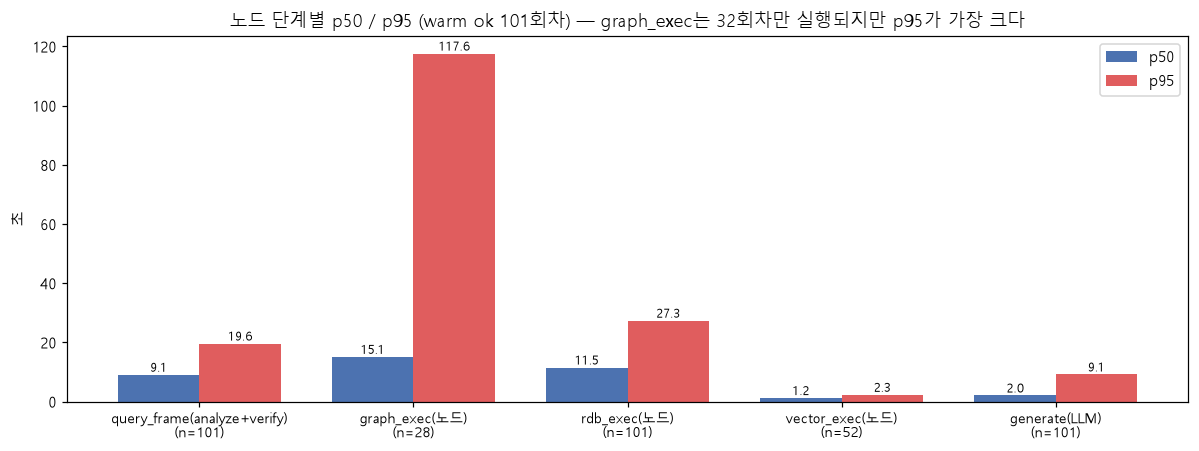

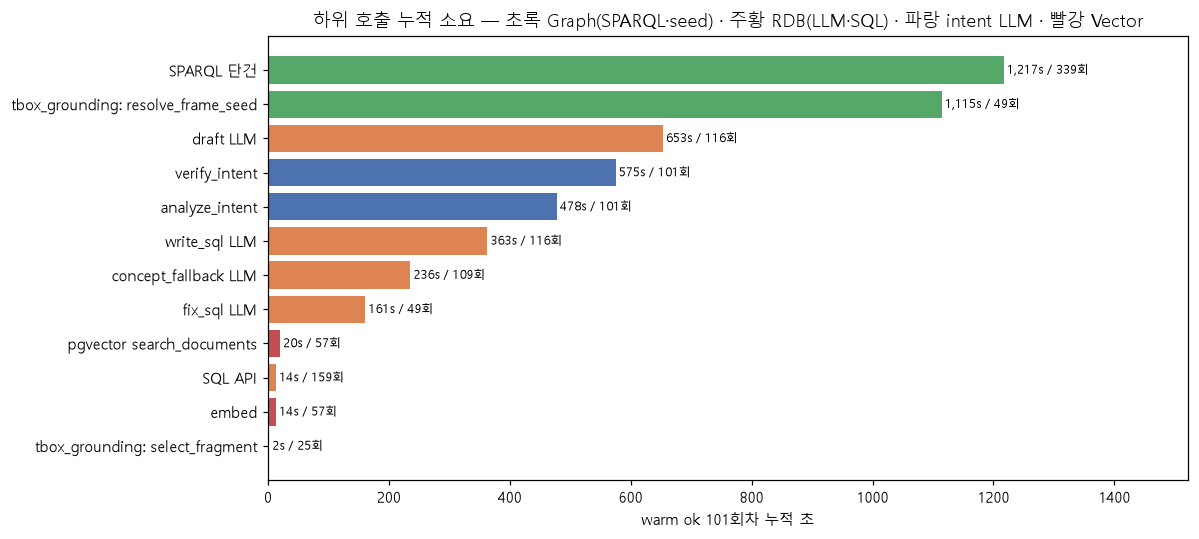

Graph 미포함 73회차 p50 23.6s / p95 38.4s · Graph 포함 28회차 p50 46.8s / p95 176.7s
LLM 호출 시간 합 p50 23.6s = E2E의 68.4%


In [4]:
# ▶ 단계·하위 호출 시간 재계산
# 4.1 단계별 시간 — traces_full.jsonl의 노드·하위 호출 시간에서 재계산 (warm ok 회차)
STAGE_NODES = {"query_frame(analyze+verify)": ["analyze_intent_node", "verify_intent_node"],
               "└ analyze_intent": ["analyze_intent_node"], "└ verify_intent": ["verify_intent_node"],
               "plan/route_guard": ["plan_query_node"], "graph_exec(노드)": ["graph_search_node"],
               "rdb_exec(노드)": ["rdb_search_node"], "vector_exec(노드)": ["vector_search_node"],
               "merge": ["merge_results_node"], "generate(LLM)": ["generate_answer_node"]}
warm_ok = [t for t in traces if t["round"] >= 2 and t["status"] == "ok"]

rows = []
for label, nodes in STAGE_NODES.items():
    vals = []
    for t in warm_ok:
        ms = sum(n["ms"] for n in t["timing"]["nodes"] if n["name"] in nodes)
        present = any(n["name"] in nodes for n in t["timing"]["nodes"])
        if present:
            vals.append(ms)
    rows.append([label, len(vals), pct(vals, .5), pct(vals, .95), max(vals) if vals else None])
# 하위 호출(LLM·SQL·SPARQL·임베딩·벡터DB)
SUB = [("graph_sub", "resolve_frame_seed", "└ tbox_grounding: resolve_frame_seed"),
       ("graph_sub", "select_fragment", "└ tbox_grounding: select_fragment"),
       ("graph_sub", "sparql", "└ SPARQL 단건"),
       ("rdb_llm", "concept_fallback", "└ concept_fallback LLM"), ("rdb_llm", "draft", "└ draft LLM"),
       ("rdb_llm", "write_sql", "└ write_sql LLM"), ("rdb_llm", "fix_sql", "└ fix_sql LLM"),
       ("rdb_sql", "run_sql", "└ SQL API"), ("embed", "embed", "└ embed"),
       ("vector_db", "search_documents", "└ pgvector search_documents")]
for key, name, label in SUB:
    vals = [x["ms"] for t in warm_ok for x in t["timing"].get(key, []) if x.get("name") == name]
    rows.append([label, len(vals), pct(vals, .5), pct(vals, .95), max(vals) if vals else None])
e2e = [t["e2e_ms"] for t in warm_ok]
rows.append(["E2E", len(e2e), pct(e2e, .5), pct(e2e, .95), max(e2e)])
stage_df = pd.DataFrame(rows, columns=["단계", "n", "p50 ms", "p95 ms", "max ms"])
display(stage_df.style.format({"p50 ms": "{:,.0f}", "p95 ms": "{:,.0f}", "max ms": "{:,.0f}"}).hide(axis="index"))

# 그래프: 노드 단계 p50/p95 (LLM이 든 단계는 빗금)
plot_df = stage_df[stage_df["단계"].isin(["query_frame(analyze+verify)", "graph_exec(노드)", "rdb_exec(노드)",
                                          "vector_exec(노드)", "generate(LLM)"])].set_index("단계")
fig, ax = plt.subplots(figsize=(11, 4.2))
x = range(len(plot_df)); wdt = 0.38
ax.bar([i - wdt/2 for i in x], plot_df["p50 ms"] / 1000, wdt, label="p50", color="#4c72b0")
ax.bar([i + wdt/2 for i in x], plot_df["p95 ms"] / 1000, wdt, label="p95", color="#d62728", alpha=0.75)
for i, (p50, p95) in enumerate(zip(plot_df["p50 ms"], plot_df["p95 ms"])):
    ax.text(i - wdt/2, p50/1000 + 1, f"{p50/1000:.1f}", ha="center", fontsize=8)
    ax.text(i + wdt/2, p95/1000 + 1, f"{p95/1000:.1f}", ha="center", fontsize=8)
ax.set_xticks(list(x)); ax.set_xticklabels([f"{i}\n(n={n})" for i, n in zip(plot_df.index, plot_df["n"])], fontsize=9)
ax.set_ylabel("초"); ax.set_title("노드 단계별 p50 / p95 (warm ok 101회차) — graph_exec는 32회차만 실행되지만 p95가 가장 크다")
ax.legend(); plt.tight_layout(); plt.show()

# 하위 호출 그래프: 어디서 시간이 새는가
sub_df = stage_df[stage_df["단계"].str.startswith("└")].copy()
sub_df["단계"] = sub_df["단계"].str.replace("└ ", "")
sub_df["합계 s"] = 0.0
for key, name, label in SUB:
    total = sum(x["ms"] for t in warm_ok for x in t["timing"].get(key, []) if x.get("name") == name) / 1000
    sub_df.loc[sub_df["단계"] == label.replace("└ ", ""), "합계 s"] = total
for nm, nodes in [("analyze_intent", ["analyze_intent_node"]), ("verify_intent", ["verify_intent_node"])]:
    total = sum(n["ms"] for t in warm_ok for n in t["timing"]["nodes"] if n["name"] in nodes) / 1000
    sub_df.loc[sub_df["단계"] == nm, "합계 s"] = total
sub_df = sub_df.sort_values("합계 s", ascending=True)
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#55a868" if "SPARQL" in s or "tbox" in s else "#dd8452" if ("LLM" in s or "SQL" in s) else "#c44e52" if ("embed" in s or "pgvector" in s) else "#4c72b0" for s in sub_df["단계"]]
ax.barh(sub_df["단계"], sub_df["합계 s"], color=colors)
for i, (v, n) in enumerate(zip(sub_df["합계 s"], sub_df["n"])):
    ax.text(v + 5, i, f"{v:,.0f}s / {n}회", va="center", fontsize=8)
ax.set_xlabel("warm ok 101회차 누적 초"); ax.set_title("하위 호출 누적 소요 — 초록 Graph(SPARQL·seed) · 주황 RDB(LLM·SQL) · 파랑 intent LLM · 빨강 Vector")
ax.set_xlim(0, sub_df["합계 s"].max() * 1.25); plt.tight_layout(); plt.show()

# 라우트별 E2E
g_runs = [t["e2e_ms"] for t in warm_ok if "graph_search_node" in {n["name"] for n in t["timing"]["nodes"]}]
ng_runs = [t["e2e_ms"] for t in warm_ok if "graph_search_node" not in {n["name"] for n in t["timing"]["nodes"]}]
print(f"Graph 미포함 {len(ng_runs)}회차 p50 {pct(ng_runs,.5)/1000:.1f}s / p95 {pct(ng_runs,.95)/1000:.1f}s · "
      f"Graph 포함 {len(g_runs)}회차 p50 {pct(g_runs,.5)/1000:.1f}s / p95 {pct(g_runs,.95)/1000:.1f}s")
llm_ms = [sum(x["ms"] for x in t["timing"]["llm"]) for t in warm_ok]
print(f"LLM 호출 시간 합 p50 {pct(llm_ms,.5)/1000:.1f}s = E2E의 {sum(llm_ms)/sum(e2e)*100:.1f}%")

### 4.2 폴백·재시도 이벤트 (warm ok 101회차)

| 이벤트 | 횟수 | 소요 합계 ms | E2E 합계 대비 |
|---|---:|---:|---:|
| SQL fix 재시도(LLM) | 49 | 161,275 | 4.0% |
| 개념 LLM 폴백(concept_fallback) | 109 | 235,693 | 5.8% |
| Graph plan 교정 재시도 | 0 | 0 | 0% (fast-path plan만 사용됨) |
| Oxigraph transport 폴백 | 0 | 0 | 0% |
| 429(파이프라인 내부) | 1 (Q21 r3) | 제외 | - |
| 합계 | - | 396,968 | 9.8% |

이벤트,횟수,소요 합계 ms,E2E 합계 대비 %
SQL fix 재시도(LLM),49,"161,275",4.0
개념 LLM 폴백(concept_fallback),109,"235,693",5.8
Graph plan 교정 재시도,0,0,0.0
Oxigraph transport 폴백,0,0,0.0


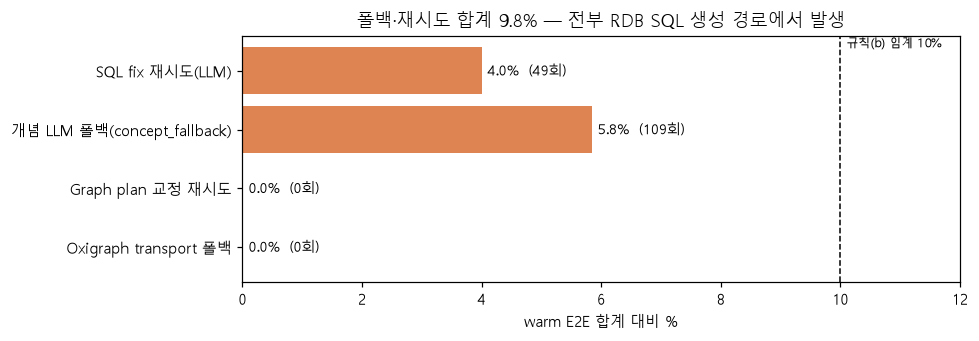

In [5]:
# ▶ 폴백 비율
# 4.2 폴백·재시도 이벤트 — 누적 시간과 E2E 대비 비율
b = S["rules"]["b_detail"]
fb = pd.DataFrame([
    ["SQL fix 재시도(LLM)", b["sql_retries"], b["fix_sql_ms"]],
    ["개념 LLM 폴백(concept_fallback)", sum(1 for t in warm_ok for x in t["timing"].get("rdb_llm", []) if x["name"] == "concept_fallback"), b["concept_fallback_ms"]],
    ["Graph plan 교정 재시도", 0, b["graph_plan_retry_ms"]],
    ["Oxigraph transport 폴백", b["graph_transport_fallback"], 0.0],
], columns=["이벤트", "횟수", "소요 합계 ms"])
fb["E2E 합계 대비 %"] = fb["소요 합계 ms"] / sum(e2e) * 100
display(fb.style.format({"소요 합계 ms": "{:,.0f}", "E2E 합계 대비 %": "{:.1f}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(fb["이벤트"], fb["E2E 합계 대비 %"], color="#dd8452")
for i, (v, n) in enumerate(zip(fb["E2E 합계 대비 %"], fb["횟수"])):
    ax.text(v + 0.1, i, f"{v:.1f}%  ({n}회)", va="center", fontsize=9)
ax.axvline(10, color="black", ls="--", lw=1); ax.text(10.1, -0.4, "규칙(b) 임계 10%", fontsize=8)
ax.set_xlim(0, 12); ax.invert_yaxis(); ax.set_xlabel("warm E2E 합계 대비 %")
ax.set_title(f"폴백·재시도 합계 {S['rules']['b_fallback_ratio']*100:.1f}% — 전부 RDB SQL 생성 경로에서 발생")
plt.tight_layout(); plt.show()

### 4.3 채점 결과 상세

### 표 1. 질의별 결과 (warm 2~4회차, ms는 중앙값)

| ID | 질문 | 루브릭 유형 | 라우트 | 정답 | E2E p50 | E2E p95 | frame ms | plan ms | graph ms | rdb ms | vector ms | generate ms | LLM 호출 | 실패신호 | 오답 원인코드 |
|---|---|---|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---|---|
| Q1 | 최신 상품정보 갱신일 기준으로 에스케이하이닉스224-2의 발행사, 신 | 부분산출 | rdb_only+vector | X(0/3) | 24,712 | 26,933 | 9,159 | 0 | 0 | 12,875 | 1,222 | 2,734 | 6 | vector_narrative:0행×3 | C×3 STALE_DEFINITION×3 |
| Q2 | 국고채권 02000-3106(21-5)의 발행일, 만기일, 잔존일수, | 산출가능 | rdb_only | O(3/3) | 20,960 | 23,707 | 6,782 | 0 | 0 | 10,723 | 0 | 3,442 | 6 | - | - - |
| Q3 | 현대해상화재보험7(후)(콜/후)의 채권 종류, 발행사, 신용등급, 만 | 산출가능 | rdb_only+vector | X(0/3) | 14,774 | 19,506 | 12,132 | 0 | 0 | 1,011 | 1,035 | 0 | 3 | rdb_채권:skipped×2, vector_narrative:0행×2 | C×3 QUERY_GENERATION_ERROR×2, RETRIEVAL_MISS×1 |
| Q4 | KODEX 200의 운용사, 기초지수, 현재 AUM, NAV, 종가, | 산출가능 | rdb_only | X(0/3) | 19,382 | 20,976 | 8,340 | 0 | 0 | 9,926 | 0 | 1,622 | 6 | - | C×3 GENERATION_OMISSION×3, RETRIEVAL_MISS×3 |
| Q5 | TIGER 미국S&P500의 투자자산군, 투자지역, 운용전략, 복제방 | 산출가능 | rdb_only+vector | X(0/3) | 23,992 | 24,186 | 7,265 | 0 | 0 | 10,155 | 1,618 | 3,551 | 6 | vector_narrative:0행×3 | C×3 GENERATION_OMISSION×3, RETRIEVAL_MISS×3 |
| Q6 | VOO의 정식 상품명, 기초지수, 운용사, 총보수, AUM, 현재가와 | 부분산출 | rdb_only | X(0/3) | 20,361 | 24,998 | 6,958 | 0 | 0 | 11,531 | 0 | 0 | 5 | rdb_해외ETF:0행×2, rdb_해외ETF:error×1, vector_narrative:0행×1 | C×3 GENERATION_OMISSION×2, RETRIEVAL_MISS×2, QUERY_EXECUTION_ERROR×1 |
| Q7 | BND의 투자자산 유형, 투자지역, 기초지수, 지수 복제방식, 운용전 | 산출가능 | rdb_only+vector | X(0/3) | 25,134 | 25,278 | 6,700 | 0 | 0 | 18,041 | 284 | 0 | 7 | vector_narrative:0행×3, rdb_펀드:error×2, rdb_펀드:0행×1 | D×3 ROUTING_MISS×3, QUERY_EXECUTION_ERROR×2, RETRIEVAL_MISS×1 |
| Q8 | 미래에셋코어테크증권자투자신탁(주식) 종류A의 펀드 유형, 순자산, 1 | 산출가능 | rdb_only | O(3/3) | 26,698 | 30,236 | 11,103 | 0 | 0 | 11,748 | 0 | 3,837 | 6 | - | - - |
| Q9 | 삼성 베스트 MMF 법인 제1호의 벤치마크, 통화, 투자지역, 개인· | 산출가능 | rdb_only+vector | O(3/3) | 19,821 | 20,469 | 6,538 | 0 | 0 | 10,051 | 1,023 | 2,706 | 6 | - | - - |
| Q10 | 우리반도체BIG2플러스의 C-P와 C-Pe 클래스가 동일한 모펀드의  | 산출가능 | graph_then_rdb+vector | X(0/3) | 140,842 | 152,805 | 13,655 | 0 | 107,584 | 14,729 | 1,146 | 3,550 | 6 | graph_R2:abstain_entity_not_found×3, graph_R3:abstain_entity_not_found×3, vector_narrative:0행×3 | C×3 GENERATION_OMISSION×3, QUERY_GENERATION_ERROR×3 |
| Q11 | 최신 갱신일 기준 매수가능수량이 0보다 큰 원화채권 중 신용등급이 A | 정의변경 | rdb_only | X(0/3) | 29,816 | 31,889 | 12,474 | 0 | 0 | 9,993 | 0 | 7,313 | 6 | exception×1 | C×2/F×1 RETRIEVAL_MISS×3, STALE_DEFINITION×3, GENERATION_OMISSION×1 |
| Q12 | 현재 판매 중이고 거래정지가 아니며 연금거래가 가능한 국내 ETF를  | 산출가능 | rdb_only | X(0/3) | 24,537 | 24,893 | 13,555 | 0 | 0 | 10,743 | 0 | 0 | 5 | rdb_국내ETF:0행×3 | C×3 FILTER_ERROR×3, GENERATION_OMISSION×3, RETRIEVAL_MISS×3 |
| Q13 | 매수 가능한 회사채 중 AA- 이상이고 잔존기간이 3년 이하인 종목을 | 정의변경 | rdb_only | X(0/3) | 36,138 | 40,206 | 12,372 | 0 | 0 | 14,972 | 0 | 8,776 | 7 | exception×1 | C×2/F×1 GENERATION_OMISSION×3, STALE_DEFINITION×3, INFRA_EXCEPTION×1 |
| Q14 | 담보부 또는 보증채 중 AAA 등급인 종목을 발행잔액 순으로 정리해줘 | 부분산출 | rdb_only | X(0/3) | 24,622 | 25,298 | 7,491 | 0 | 0 | 10,088 | 0 | 7,031 | 6 | exception×1 | C×2/F×1 RETRIEVAL_MISS×3, GENERATION_OMISSION×2, INFRA_EXCEPTION×1 |
| Q15 | 해외주식에 투자하는 패시브·실물복제·정방향 ETF 중 순자산 1조 원 | 산출가능 | rdb_only | X(0/3) | 22,652 | 23,023 | 11,207 | 0 | 0 | 10,033 | 0 | 0 | 5 | rdb_해외ETF:0행×2 | D×3 GENERATION_OMISSION×3, RETRIEVAL_MISS×3, ROUTING_MISS×3 |
| Q16 | 섹터·테마형 액티브 ETF 중 순자산 5천억 원 이상인 상품을 찾아  | 부분산출 | rdb_only+vector | X(0/3) | 30,282 | 38,432 | 7,897 | 0 | 0 | 13,568 | 1,735 | 7,047 | 7 | - | D×3 ROUTING_MISS×3, GENERATION_OMISSION×2 |
| Q17 | 미국 주식형 ETF 중 AUM이 1천억 달러 이상이고 총보수가 0.0 | 산출가능 | rdb_only | X(0/3) | 22,332 | 23,454 | 8,895 | 0 | 0 | 13,021 | 0 | 0 | 6 | rdb_해외ETF:0행×2 | C×2/E×1 GENERATION_OMISSION×3, FILTER_ERROR×2, RETRIEVAL_MISS×2 |
| Q18 | 해외 채권 ETF 중 총보수가 0.10% 이하인 상품을 AUM 순으로 | 산출가능 | rdb_only | X(0/3) | 29,876 | 30,128 | 8,656 | 0 | 0 | 12,311 | 0 | 9,148 | 7 | - | C×3 FILTER_ERROR×3, GENERATION_OMISSION×3 |
| Q19 | 판매 중인 공모펀드 가운데 1년 수익률이 양수이고 순자산이 1천억 원 | 산출가능 | rdb_only | X(0/3) | 23,560 | 24,939 | 11,644 | 0 | 0 | 11,860 | 0 | 0 | 5 | rdb_펀드:0행×3 | C×3 FILTER_ERROR×3, GENERATION_OMISSION×3, RETRIEVAL_MISS×3 |
| Q20 | 국내 반도체에 투자하는 ETF와 공모펀드를 통합 검색해 순자산 상위  | 부분산출 | rdb_only+vector | X(0/3) | 34,818 | 35,742 | 8,681 | 0 | 0 | 18,455 | 2,299 | 4,564 | 7 | rdb_펀드:0행×3 | C×3 GENERATION_OMISSION×3, RETRIEVAL_MISS×3, WRONG_VALUE×3 |
| Q21 | KODEX200이 국내 ETF 데이터와 공모펀드 데이터에 모두 나타나 | 산출가능 | rdb_only+vector | X(0/2) | 34,020 | 36,129 | 7,811 | 0 | 0 | 21,182 | 1,848 | 3,168 | 9 | rdb_펀드:0행×2, vector_narrative:0행×2, rdb_국내ETF:0행×1, rate_limited×1 | C×1/E×1 RETRIEVAL_MISS×1, GENERATION_OMISSION×1 |
| Q22 | 캠브리콘이 실제 편입된 중국 반도체 ETF를 찾아줘. ETF→편입증권 | 외부데이터필요 | graph_then_rdb | △(1/3) | 40,310 | 121,272 | 9,514 | 0 | 14,171 | 10,763 | 0 | 1,623 | 6 | graph_R1:abstain_entity_not_found×2, graph_R2:abstain_entity_not_found×1, graph_R3:abstain_entity_not_found×1, graph_R4:abstain_entity_not_found×1 | E×2 GENERATION_OMISSION×2 |
| Q23 | 최근 6개월 동안 우주항공 테마와 연결된 이력이 있는 ETF를 정리해 | 부분산출 | graph_then_rdb | X(0/3) | 145,989 | 166,062 | 20,780 | 0 | 91,743 | 27,265 | 0 | 7,644 | 9 | graph_R2:abstain_entity_not_found×3, graph_R3:abstain_entity_not_found×3, graph_R4:abstain_entity_not_found×3, rdb_해외ETF:skipped×3 | E×3 UNSUPPORTED_INFERENCE×3 |
| Q24 | 에코프로의 자회사를 편입한 ETF를 찾고 그중 최신 AUM이 가장 큰 | 외부데이터필요 | graph_then_rdb+vector | △(2/3) | 30,841 | 38,439 | 13,988 | 0 | 99 | 11,355 | 683 | 4,798 | 6 | graph_R3:abstain_evidence_missing×3, rdb_국내ETF:0행×2, vector_narrative:0행×1 | E×1 GENERATION_OMISSION×1 |
| Q25 | 국민성장펀드의 구조, 운용주체, 자금조달 방식과 최근 투자전략 동향을 | 부분산출 | rdb_only+vector | X(0/3) | 19,520 | 21,333 | 8,941 | 0 | 0 | 10,124 | 258 | 0 | 5 | rdb_펀드:0행×3, vector_narrative:0행×3 | C×3 FILTER_ERROR×3, RETRIEVAL_MISS×3 |
| Q26 | SK하이닉스가 발행한 매수 가능 채권과 SK하이닉스를 편입한 ETF· | 부분산출 | graph_then_rdb+vector | X(0/3) | 176,711 | 188,884 | 20,398 | 0 | 108,237 | 46,336 | 1,601 | 1,882 | 15 | vector_narrative:0행×3, graph_R1:abstain_evidence_missing×2, graph_R2:abstain_entity_not_found×2, graph_R3:abstain_evidence_missing×2 | C×3 GENERATION_OMISSION×3, RETRIEVAL_MISS×2, UNSUPPORTED_INFERENCE×2 |
| Q27 | LG에너지솔루션 및 확인된 자회사가 발행한 채권과 이 기업들을 편입한 | 부분산출 | graph_then_rdb+vector | X(0/3) | 96,790 | 113,719 | 16,561 | 0 | 54,412 | 23,106 | 1,595 | 4,976 | 11 | graph_R3:abstain_entity_not_found×3, graph_R4:abstain_evidence_missing×3, vector_narrative:0행×3, graph_R2:abstain_invalid_graph_plan×2 | C×3 GENERATION_OMISSION×3, RETRIEVAL_MISS×3 |
| Q28 | 엔비디아를 편입한 국내 ETF와 해외 ETF 중 순자산이 큰 상품을  | 외부데이터필요 | graph_then_rdb+vector | △(1/3) | 41,996 | 46,948 | 13,625 | 0 | 610 | 21,363 | 1,188 | 3,569 | 7 | rdb_해외ETF:0행×3, vector_narrative:0행×1, rdb_국내ETF:error×1 | C×1/E×1 FILTER_ERROR×1, UNGROUNDED_CLAIM×1, UNSUPPORTED_INFERENCE×1 |
| Q29 | VOO, IVV, SPY가 같은 S&P 500 계열 지수를 추종하는지 | 부분산출 | graph_then_rdb+vector | X(0/3) | 37,014 | 38,356 | 12,561 | 0 | 13,998 | 10,671 | 279 | 0 | 5 | graph_R1:abstain_entity_not_found×3, rdb_국내ETF:0행×3, vector_narrative:0행×3 | D×3 GENERATION_OMISSION×3, RETRIEVAL_MISS×3, ROUTING_MISS×3 |
| Q30 | 우리반도체BIG2플러스 펀드와 국내 반도체 ETF의 실제 편입종목 중 | 외부데이터필요 | rdb_only+vector | X(0/3) | 39,369 | 47,348 | 8,785 | 0 | 0 | 25,887 | 1,212 | 2,698 | 9 | rdb_국내ETF:error×1 | C×3 FILTER_ERROR×3, GENERATION_OMISSION×3 |
| Q31 | 신용등급이 AAAA인 매수 가능 채권을 찾아 상품번호와 신용평가 근거 | ABSTAIN | rdb_only | X(0/3) | 11,065 | 11,134 | 9,223 | 0 | 0 | 1,686 | 0 | 0 | 3 | rdb_채권:skipped×3 | E×3 MISSING_EVIDENCE×3 |
| Q32 | 2026-08-24 기준으로 Kimi 관련 투자 상품을 찾아 해당 모 | ABSTAIN | rdb_only | △(1/3) | 26,418 | 28,308 | 6,585 | 0 | 0 | 15,905 | 0 | 0 | 7 | rdb_펀드:0행×2, graph_R1:abstain_entity_not_found×1 | D×2 MISSING_EVIDENCE×2 |
| Q33 | KODEX AI로봇 ETF의 수익률과 편입종목을 공식 문서 근거로 알 | ABSTAIN | rdb_only+vector | X(0/3) | 14,886 | 15,713 | 6,710 | 0 | 0 | 8,151 | 254 | 0 | 5 | rdb_국내ETF:0행×3, vector_narrative:0행×3 | D×3 MISSING_EVIDENCE×3 |
| Q34 | TIGER 미국S&P500의 2027년 확정 연간수익률을 데이터 근거 | ABSTAIN | rdb_only+vector | △(1/3) | 16,011 | 18,275 | 6,607 | 0 | 0 | 8,538 | 342 | 0 | 5 | vector_narrative:0행×3, rdb_해외ETF:0행×2 | D×2 MISSING_EVIDENCE×2 |
| Q35 | VOO가 직접 발행한 회사채의 신용등급과 만기일을 알려줘. | ABSTAIN | graph+rdb(parallel) | X(0/3) | 23,976 | 46,803 | 6,711 | 0 | 16,202 | 6,429 | 0 | 1,786 | 5 | graph_R1:abstain_entity_not_found×3 | D×3 MISSING_EVIDENCE×3 |

In [6]:
# ▶ 표 1 DataFrame
# 표 1을 DataFrame으로 (정렬·필터 가능) — 원본 값은 analysis_summary.json
t1 = Q[["question", "type", "route", "correct", "pass", "n_scored", "e2e_p50", "e2e_p95", "frame", "rdb", "graph",
        "vector", "generate", "llm_calls", "signals", "codes", "cause"]].copy()
t1.columns = ["질문", "루브릭 유형", "라우트", "정답", "정답 회차", "채점 회차", "E2E p50", "E2E p95", "frame ms", "rdb ms",
              "graph ms", "vector ms", "generate ms", "LLM 호출", "실패신호", "실패코드", "오답 원인"]
display(t1.style.format({c: "{:,.0f}" for c in ["E2E p50", "E2E p95", "frame ms", "rdb ms", "graph ms", "vector ms", "generate ms"]})
        .background_gradient(subset=["E2E p95"], cmap="Reds")
        .map(lambda v: "background-color:#d4edda" if v == "O" else ("background-color:#fff3cd" if v == "△" else "background-color:#f8d7da"), subset=["정답"]))

,질문,루브릭 유형,라우트,정답,정답 회차,채점 회차,E2E p50,E2E p95,frame ms,rdb ms,graph ms,vector ms,generate ms,LLM 호출,실패신호,실패코드,오답 원인
id,,,,,,,,,,,,,,,,,
Q1,"최신 상품정보 갱신일 기준으로 에스케이하이닉스224-2의 발행사, 신",부분산출,rdb_only+vector,X,0,3,"24,712","26,933","9,159","12,875",0,"1,222","2,734",6.000000,vector_narrative:0행×3,STALE_DEFINITION×3,C×3
Q2,"국고채권 02000-3106(21-5)의 발행일, 만기일, 잔존일수,",산출가능,rdb_only,O,3,3,"20,960","23,707","6,782","10,723",0,0,"3,442",6.000000,-,-,-
Q3,"현대해상화재보험7(후)(콜/후)의 채권 종류, 발행사, 신용등급, 만",산출가능,rdb_only+vector,X,0,3,"14,774","19,506","12,132","1,011",0,"1,035",0,3.000000,"rdb_채권:skipped×2, vector_narrative:0행×2","QUERY_GENERATION_ERROR×2, RETRIEVAL_MISS×1",C×3
Q4,"KODEX 200의 운용사, 기초지수, 현재 AUM, NAV, 종가,",산출가능,rdb_only,X,0,3,"19,382","20,976","8,340","9,926",0,0,"1,622",6.000000,-,"GENERATION_OMISSION×3, RETRIEVAL_MISS×3",C×3
Q5,"TIGER 미국S&P500의 투자자산군, 투자지역, 운용전략, 복제방",산출가능,rdb_only+vector,X,0,3,"23,992","24,186","7,265","10,155",0,"1,618","3,551",6.000000,vector_narrative:0행×3,"GENERATION_OMISSION×3, RETRIEVAL_MISS×3",C×3
Q6,"VOO의 정식 상품명, 기초지수, 운용사, 총보수, AUM, 현재가와",부분산출,rdb_only,X,0,3,"20,361","24,998","6,958","11,531",0,0,0,5.000000,"rdb_해외ETF:0행×2, rdb_해외ETF:error×1, vector_narrative:0행×1","GENERATION_OMISSION×2, RETRIEVAL_MISS×2, QUERY_EXECUTION_ERROR×1",C×3
Q7,"BND의 투자자산 유형, 투자지역, 기초지수, 지수 복제방식, 운용전",산출가능,rdb_only+vector,X,0,3,"25,134","25,278","6,700","18,041",0,284,0,7.000000,"vector_narrative:0행×3, rdb_펀드:error×2, rdb_펀드:0행×1","ROUTING_MISS×3, QUERY_EXECUTION_ERROR×2, RETRIEVAL_MISS×1",D×3
Q8,"미래에셋코어테크증권자투자신탁(주식) 종류A의 펀드 유형, 순자산, 1",산출가능,rdb_only,O,3,3,"26,698","30,236","11,103","11,748",0,0,"3,837",6.000000,-,-,-
Q9,"삼성 베스트 MMF 법인 제1호의 벤치마크, 통화, 투자지역, 개인·",산출가능,rdb_only+vector,O,3,3,"19,821","20,469","6,538","10,051",0,"1,023","2,706",6.000000,-,-,-


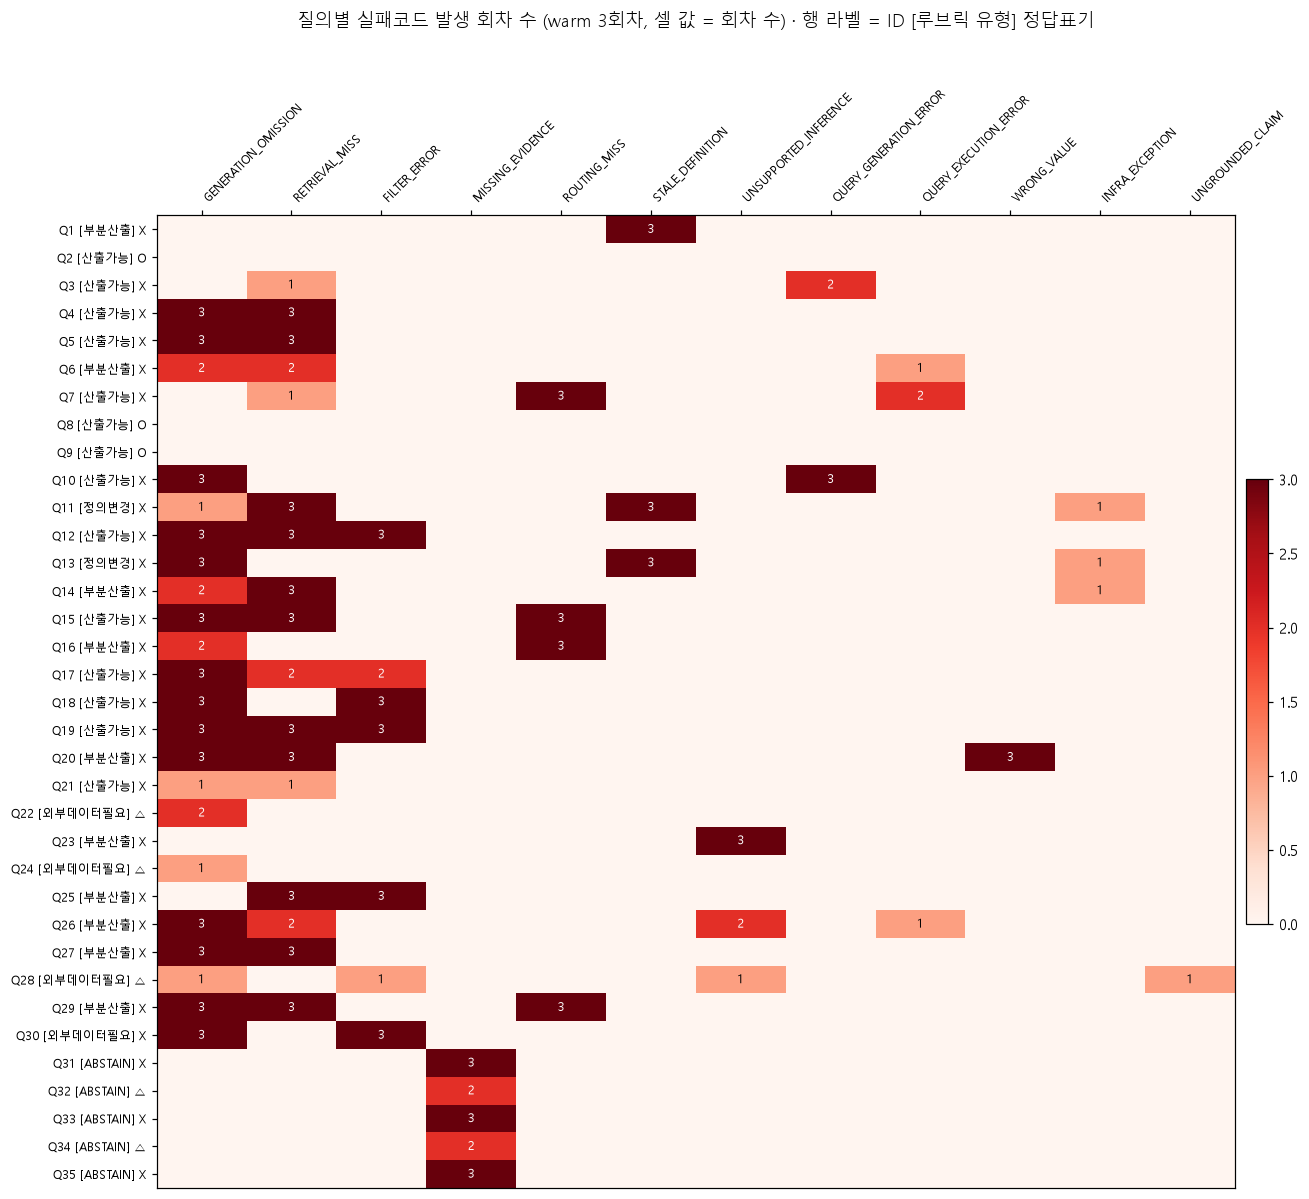

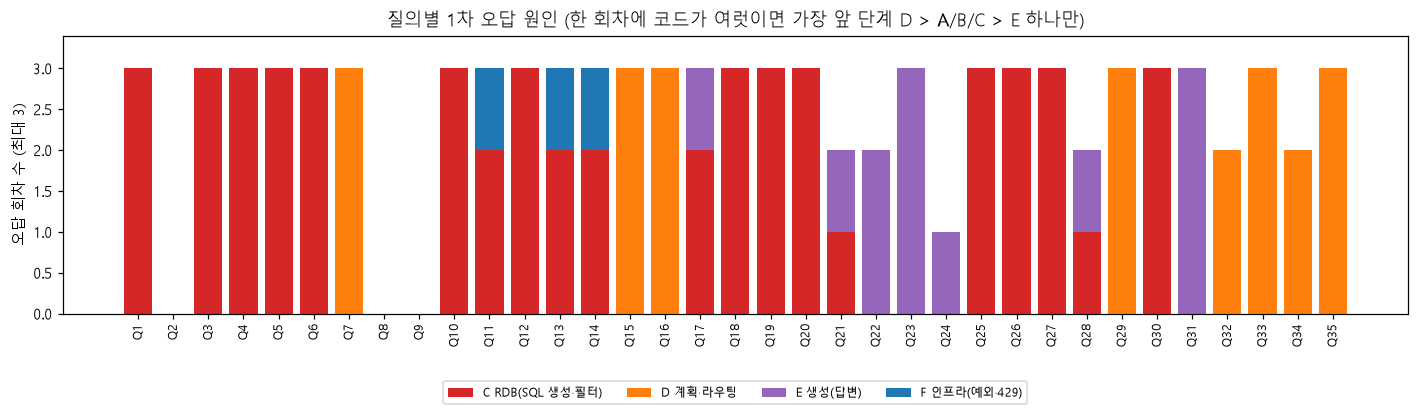

In [7]:
# ▶ 질의 × 실패코드 · 질의별 원인
# 질의별 × 실패코드 히트맵 (warm 채점 회차의 failure_codes 합산) — "어떤 문항에서 어떤 오류가 났나"
import numpy as np
code_rows = scored.explode("failure_codes").dropna(subset=["failure_codes"])
CODE_ORDER = ["GENERATION_OMISSION", "RETRIEVAL_MISS", "FILTER_ERROR", "MISSING_EVIDENCE", "ROUTING_MISS",
              "STALE_DEFINITION", "UNSUPPORTED_INFERENCE", "QUERY_GENERATION_ERROR", "QUERY_EXECUTION_ERROR",
              "WRONG_VALUE", "INFRA_EXCEPTION", "UNGROUNDED_CLAIM", "MISSED_ABSTAIN"]
CODE_ORDER = [c for c in CODE_ORDER if c in set(code_rows["failure_codes"])] + sorted(set(code_rows["failure_codes"]) - set(CODE_ORDER))
mat = pd.crosstab(code_rows["qnum"], code_rows["failure_codes"]).reindex(index=range(1, 36), columns=CODE_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(mat.values, cmap="Reds", aspect="auto", vmin=0, vmax=3)
ax.set_xticks(range(len(CODE_ORDER))); ax.set_xticklabels(CODE_ORDER, rotation=45, ha="left", fontsize=8)
ax.xaxis.tick_top()
ax.set_yticks(range(35)); ax.set_yticklabels([f"Q{i} [{Q.loc[f'Q{i}','type']}] {Q.loc[f'Q{i}','correct']}" for i in range(1, 36)], fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if v:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=8, color="white" if v >= 2 else "black")
ax.set_title("질의별 실패코드 발생 회차 수 (warm 3회차, 셀 값 = 회차 수) · 행 라벨 = ID [루브릭 유형] 정답표기", pad=40)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01); plt.tight_layout(); plt.show()

# 질의별 1차 오답 원인 (회차 수)
cause_q = pd.crosstab(wrong["qnum"], wrong["cause"]).reindex(index=range(1, 36), columns=CAUSE_ORDER, fill_value=0)
fig, ax = plt.subplots(figsize=(13, 4))
bottom = np.zeros(35)
for c in CAUSE_ORDER:
    if cause_q[c].sum() == 0:
        continue
    ax.bar([f"Q{i}" for i in range(1, 36)], cause_q[c], bottom=bottom, color=CAUSE_COLOR[c], label=CAUSE_LABEL[c])
    bottom += cause_q[c].values
ax.set_ylabel("오답 회차 수 (최대 3)"); ax.set_ylim(0, 3.4); ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.set_title("질의별 1차 오답 원인 (한 회차에 코드가 여럿이면 가장 앞 단계 D > A/B/C > E 하나만)")
ax.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.22)); plt.tight_layout(); plt.show()

### 표 2. 루브릭 유형별

| 유형 | 문항수 | 채점 회차 | 정답 회차 | 오답률 % | 평균 E2E ms | 최다 오답 원인 | 최다 실패코드 |
|---|---:|---:|---:|---:|---:|---|---|
| 산출가능 | 14 | 41 | 9 | 78.0 | 31,339 | C | GENERATION_OMISSION |
| 부분산출 | 10 | 30 | 0 | 100.0 | 61,277 | C | RETRIEVAL_MISS |
| 외부데이터필요 | 4 | 12 | 4 | 66.7 | 45,056 | E | GENERATION_OMISSION |
| 정의변경 | 2 | 6 | 0 | 100.0 | 32,977 | C | STALE_DEFINITION |
| ABSTAIN | 5 | 15 | 2 | 86.7 | 19,924 | D | MISSING_EVIDENCE |

,문항수,채점회차,정답회차,오답률 %,평균 E2E ms,최다 오답 원인,최다 실패코드
type,,,,,,,
산출가능,14,41,9,78.0,"31,339",C,GENERATION_OMISSION
부분산출,10,30,0,100.0,"61,277",C,RETRIEVAL_MISS
외부데이터필요,4,12,4,66.7,"45,056",E,GENERATION_OMISSION
정의변경,2,6,0,100.0,"32,977",C,STALE_DEFINITION
ABSTAIN,5,15,2,86.7,"19,924",D,MISSING_EVIDENCE


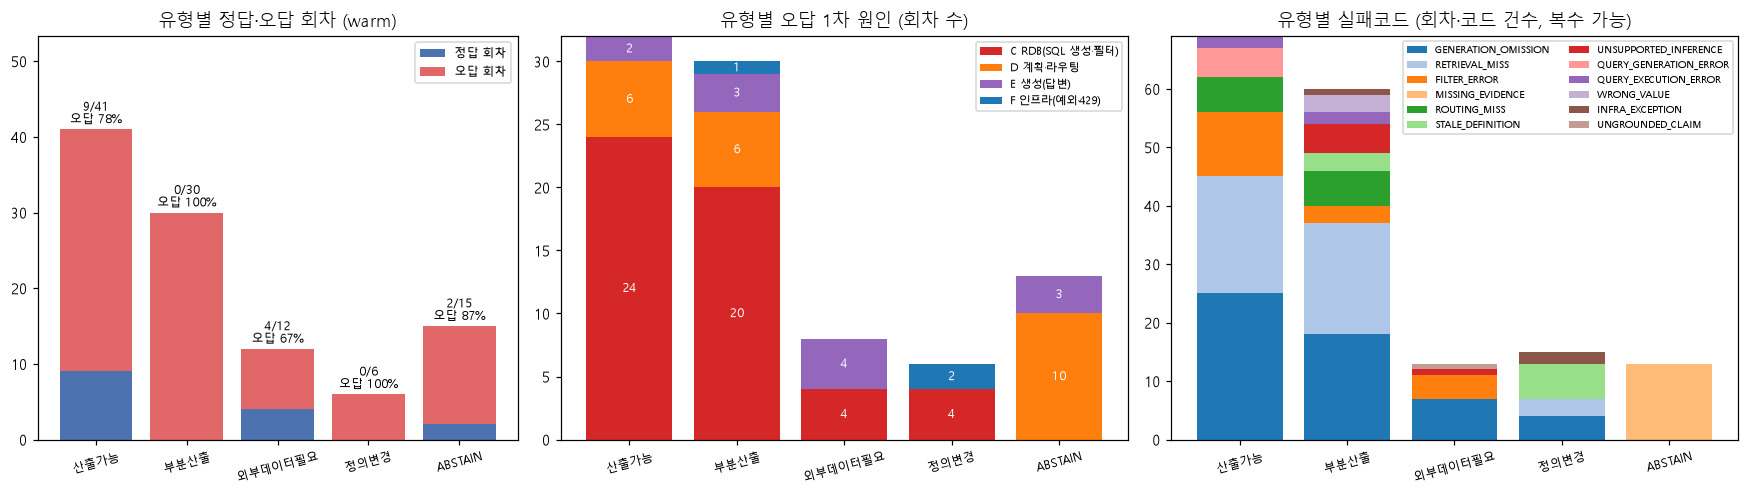

failure_codes,GENERATION_OMISSION,RETRIEVAL_MISS,FILTER_ERROR,MISSING_EVIDENCE,ROUTING_MISS,STALE_DEFINITION,UNSUPPORTED_INFERENCE,QUERY_GENERATION_ERROR,QUERY_EXECUTION_ERROR,WRONG_VALUE,INFRA_EXCEPTION,UNGROUNDED_CLAIM
type,,,,,,,,,,,,
산출가능,25,20,11,0,6,0,0,5,2,0,0,0
부분산출,18,19,3,0,6,3,5,0,2,3,1,0
외부데이터필요,7,0,4,0,0,0,1,0,0,0,0,1
정의변경,4,3,0,0,0,6,0,0,0,0,2,0
ABSTAIN,0,0,0,13,0,0,0,0,0,0,0,0


In [8]:
# ▶ 유형 × 원인 · 유형 × 실패코드
# 표 2 — 루브릭 유형별: 정답/오답 · 오답 원인 A~F · 실패코드 분포
import numpy as np
type_stats = scored.groupby("type").agg(문항수=("question_id", "nunique"), 채점회차=("question_id", "size"),
                                         정답회차=("overall_pass", lambda s: int(s.astype(bool).sum()))).reindex(TYPE_ORDER)
type_stats["오답률 %"] = (1 - type_stats["정답회차"] / type_stats["채점회차"]) * 100
type_stats["평균 E2E ms"] = [s["mean_e2e"] for s in sorted(S["types"], key=lambda s: TYPE_ORDER.index(s["type"]))]
type_stats["최다 오답 원인"] = [s["top_cause"] for s in sorted(S["types"], key=lambda s: TYPE_ORDER.index(s["type"]))]
type_stats["최다 실패코드"] = [s["top_code"] for s in sorted(S["types"], key=lambda s: TYPE_ORDER.index(s["type"]))]
display(type_stats.style.format({"오답률 %": "{:.1f}", "평균 E2E ms": "{:,.0f}"}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.1, 1.3, 1.3]})

# (1) 정답/오답 회차 적층
ax = axes[0]
ax.bar(TYPE_ORDER, type_stats["정답회차"], color="#4c72b0", label="정답 회차")
ax.bar(TYPE_ORDER, type_stats["채점회차"] - type_stats["정답회차"], bottom=type_stats["정답회차"], color="#d62728", alpha=0.7, label="오답 회차")
for i, (p, n, r) in enumerate(zip(type_stats["정답회차"], type_stats["채점회차"], type_stats["오답률 %"])):
    ax.text(i, n + 0.8, f"{p}/{n}\n오답 {r:.0f}%", ha="center", fontsize=8)
ax.set_ylim(0, type_stats["채점회차"].max() * 1.3); ax.set_title("유형별 정답·오답 회차 (warm)"); ax.legend(fontsize=8)
ax.tick_params(axis="x", labelsize=8, rotation=15)

# (2) 유형 × 오답 원인
ax = axes[1]
tc = pd.crosstab(wrong["type"], wrong["cause"]).reindex(index=TYPE_ORDER, columns=CAUSE_ORDER, fill_value=0)
bottom = np.zeros(len(TYPE_ORDER))
for c in CAUSE_ORDER:
    if tc[c].sum() == 0:
        continue
    bars = ax.bar(TYPE_ORDER, tc[c], bottom=bottom, color=CAUSE_COLOR[c], label=CAUSE_LABEL[c])
    for b, v in zip(bars, tc[c]):
        if v:
            ax.text(b.get_x() + b.get_width() / 2, b.get_y() + v / 2, str(v), ha="center", va="center", fontsize=8, color="white")
    bottom += tc[c].values
ax.set_title("유형별 오답 1차 원인 (회차 수)"); ax.legend(fontsize=7, loc="upper right"); ax.tick_params(axis="x", labelsize=8, rotation=15)

# (3) 유형 × 실패코드 (한 회차에 여러 코드 가능)
ax = axes[2]
tcode = pd.crosstab(code_rows["type"], code_rows["failure_codes"]).reindex(index=TYPE_ORDER, columns=CODE_ORDER, fill_value=0)
cmap = plt.get_cmap("tab20")
bottom = np.zeros(len(TYPE_ORDER))
for k, code in enumerate(CODE_ORDER):
    ax.bar(TYPE_ORDER, tcode[code], bottom=bottom, color=cmap(k % 20), label=code)
    bottom += tcode[code].values
ax.set_title("유형별 실패코드 (회차·코드 건수, 복수 가능)"); ax.legend(fontsize=6.5, ncol=2, loc="upper right"); ax.tick_params(axis="x", labelsize=8, rotation=15)
plt.tight_layout(); plt.show()

# 유형 × 실패코드 표 (가장 직관적인 읽기용)
display(tcode.style.background_gradient(cmap="Reds", axis=None))

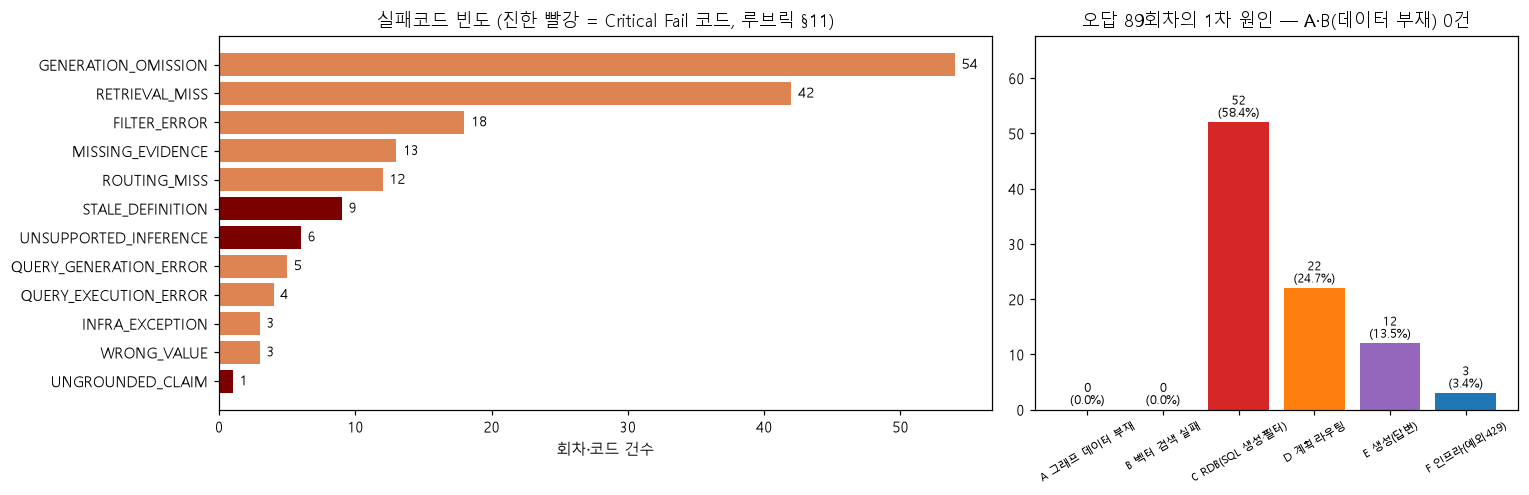

In [9]:
# ▶ 실패코드 총빈도·원인 분포
# 실패코드 총빈도와 원인코드 분포 (warm 채점 104회차 · 오답 89회차)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
cc = pd.Series(S["accuracy"]["code_counts"]).sort_values()
SEV = {"UNSUPPORTED_INFERENCE": "CRITICAL", "UNGROUNDED_CLAIM": "CRITICAL", "MISSED_ABSTAIN": "CRITICAL", "STALE_DEFINITION": "CRITICAL"}
ax.barh(cc.index, cc.values, color=["#7b0000" if SEV.get(k) == "CRITICAL" else "#dd8452" for k in cc.index])
for i, v in enumerate(cc.values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
ax.set_title("실패코드 빈도 (진한 빨강 = Critical Fail 코드, 루브릭 §11)"); ax.set_xlabel("회차·코드 건수")

ax = axes[1]
cause_counts = wrong["cause"].value_counts().reindex(CAUSE_ORDER, fill_value=0)
bars = ax.bar([CAUSE_LABEL[c] for c in CAUSE_ORDER], cause_counts.values, color=[CAUSE_COLOR[c] for c in CAUSE_ORDER])
for b, v in zip(bars, cause_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v}\n({v/len(wrong)*100:.1f}%)", ha="center", fontsize=8)
ax.set_ylim(0, cause_counts.max() * 1.3); ax.tick_params(axis="x", rotation=30, labelsize=7)
ax.set_title(f"오답 {len(wrong)}회차의 1차 원인 — A·B(데이터 부재) 0건")
plt.tight_layout(); plt.show()

,건수,전체 코드 건수 대비 %,발생 오답 회차,오답 89회차 대비 %,심각도
failure_codes,,,,,
GENERATION_OMISSION,54,31.8,54,60.7,ERROR
RETRIEVAL_MISS,42,24.7,42,47.2,ERROR
FILTER_ERROR,18,10.6,18,20.2,ERROR
MISSING_EVIDENCE,13,7.6,13,14.6,ERROR
ROUTING_MISS,12,7.1,12,13.5,ERROR
STALE_DEFINITION,9,5.3,9,10.1,CRITICAL
UNSUPPORTED_INFERENCE,6,3.5,6,6.7,CRITICAL
QUERY_GENERATION_ERROR,5,2.9,5,5.6,ERROR
QUERY_EXECUTION_ERROR,4,2.4,4,4.5,ERROR


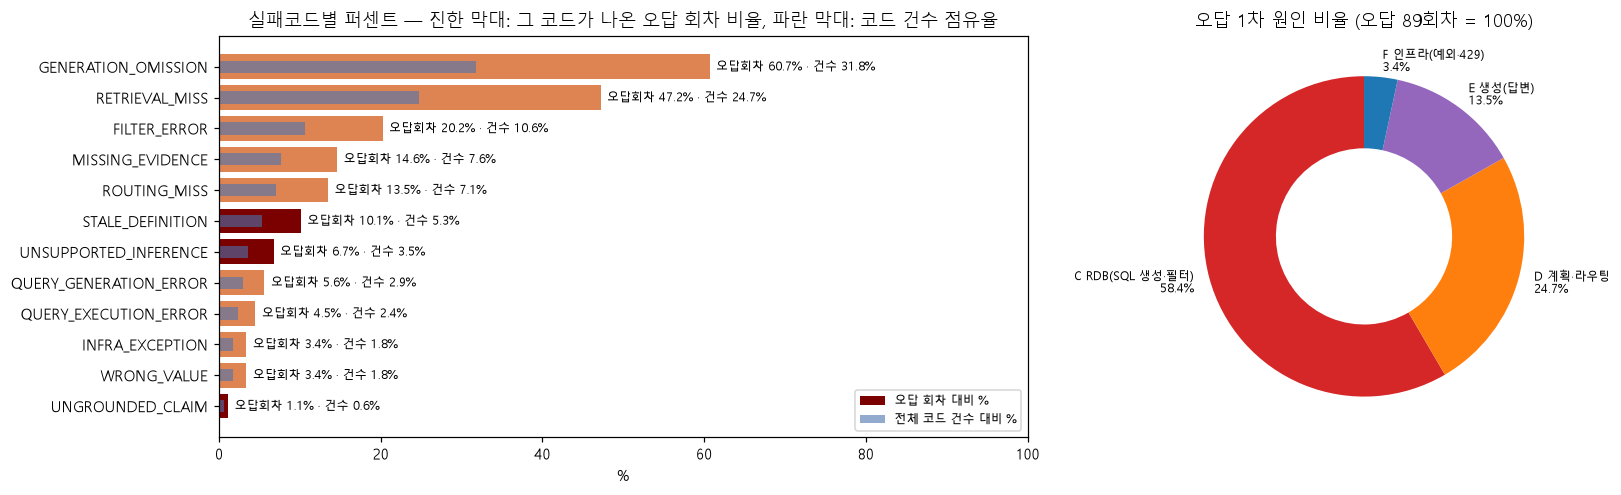

In [10]:
# ▶ 오류 유형별 퍼센트
# 오류 유형별 퍼센트 — 세 가지 분모를 나눠서 본다
# (1) 실패코드 건수 ÷ 전체 실패코드 건수  (2) 해당 코드가 나온 오답 회차 ÷ 오답 89회차  (3) 원인 A~F ÷ 오답 89회차
code_cnt = code_rows["failure_codes"].value_counts()
code_runs = code_rows.drop_duplicates(["question_id", "round", "failure_codes"])["failure_codes"].value_counts()
pct_df = pd.DataFrame({"건수": code_cnt, "전체 코드 건수 대비 %": code_cnt / code_cnt.sum() * 100,
                       "발생 오답 회차": code_runs, "오답 89회차 대비 %": code_runs / len(wrong) * 100}).fillna(0).sort_values("건수", ascending=False)
pct_df["심각도"] = [SEV.get(k, "ERROR") for k in pct_df.index]
display(pct_df.style.format({"전체 코드 건수 대비 %": "{:.1f}", "오답 89회차 대비 %": "{:.1f}", "건수": "{:.0f}", "발생 오답 회차": "{:.0f}"})
        .background_gradient(subset=["오답 89회차 대비 %"], cmap="Reds"))

cause_pct = (wrong["cause"].value_counts().reindex(CAUSE_ORDER, fill_value=0) / len(wrong) * 100)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.7, 1]})
ax = axes[0]
p = pct_df.sort_values("오답 89회차 대비 %")
ax.barh(p.index, p["오답 89회차 대비 %"], color=["#7b0000" if s == "CRITICAL" else "#dd8452" for s in p["심각도"]], label="오답 회차 대비 %")
ax.barh(p.index, p["전체 코드 건수 대비 %"], color="#4c72b0", alpha=0.6, height=0.4, label="전체 코드 건수 대비 %")
for i, (a_, b_) in enumerate(zip(p["오답 89회차 대비 %"], p["전체 코드 건수 대비 %"])):
    ax.text(max(a_, b_) + 0.8, i, f"오답회차 {a_:.1f}% · 건수 {b_:.1f}%", va="center", fontsize=8)
ax.set_xlim(0, 100); ax.set_xlabel("%"); ax.legend(loc="lower right", fontsize=8)
ax.set_title("실패코드별 퍼센트 — 진한 막대: 그 코드가 나온 오답 회차 비율, 파란 막대: 코드 건수 점유율")
ax = axes[1]
wedges, *_ = ax.pie(cause_pct[cause_pct > 0], labels=[f"{CAUSE_LABEL[c]}\n{v:.1f}%" for c, v in cause_pct[cause_pct > 0].items()],
                    colors=[CAUSE_COLOR[c] for c in cause_pct[cause_pct > 0].index], startangle=90, textprops={"fontsize": 8},
                    wedgeprops={"width": 0.45})
ax.set_title(f"오답 1차 원인 비율 (오답 {len(wrong)}회차 = 100%)")
plt.tight_layout(); plt.show()

,채점회차,정답회차,Critical없음,정답률 %,Critical 없음 %,429 재실행 문항,예외·429 회차,E2E p50 ms,E2E p95 ms
1회차 (cold),34,3,26,8.8,76.5,3,2,"24,796","82,746"
2회차,35,5,29,14.3,82.9,2,0,"25,116","145,989"
3회차,34,3,30,8.8,88.2,3,2,"24,998","152,805"
4회차,35,7,30,20.0,85.7,0,2,"24,939","140,842"


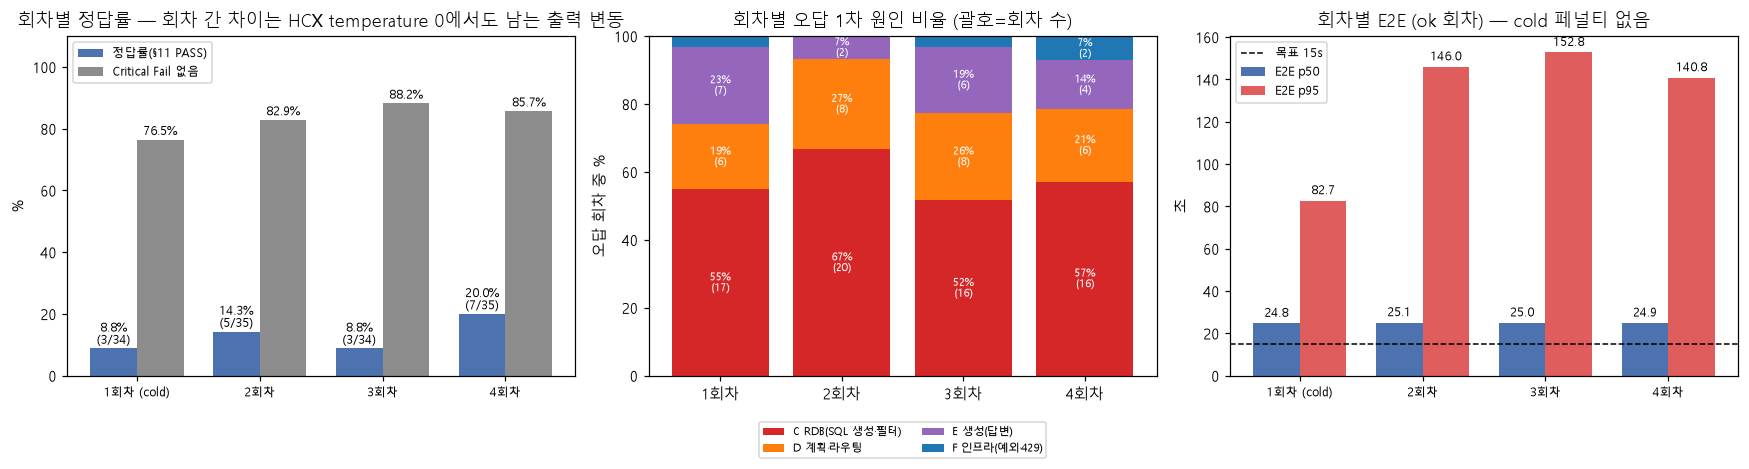

회차별 실패코드 발생 비율 (% = 그 코드가 나온 회차 ÷ 회차 채점 문항 수)


,1회차 (cold),2회차,3회차,4회차
failure_codes,,,,
GENERATION_OMISSION,52.9,45.7,55.9,54.3
RETRIEVAL_MISS,32.4,48.6,32.4,40.0
FILTER_ERROR,17.6,20.0,14.7,17.1
MISSING_EVIDENCE,11.8,14.3,14.7,8.6
ROUTING_MISS,8.8,11.4,11.8,11.4
STALE_DEFINITION,8.8,8.6,8.8,8.6
UNSUPPORTED_INFERENCE,8.8,8.6,2.9,5.7
QUERY_GENERATION_ERROR,5.9,2.9,5.9,5.7
QUERY_EXECUTION_ERROR,5.9,0.0,8.8,2.9


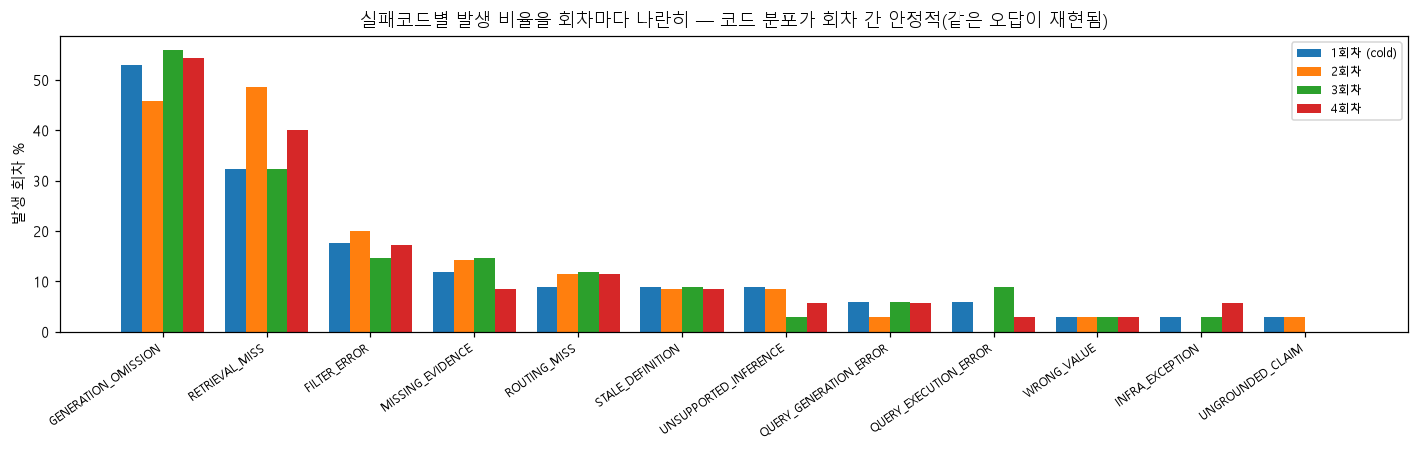

,1회차,2회차,3회차,4회차,유형,정답 회차/채점
Q1,X,X,X,X,부분산출,0/3
Q2,O,O,O,O,산출가능,3/3
Q3,X,X,X,X,산출가능,0/3
Q4,X,X,X,X,산출가능,0/3
Q5,X,X,X,X,산출가능,0/3
Q6,X,X,X,X,부분산출,0/3
Q7,X,X,X,X,산출가능,0/3
Q8,O,O,O,O,산출가능,3/3
Q9,O,O,O,O,산출가능,3/3
Q10,X,X,X,X,산출가능,0/3


In [11]:
# ▶ 회차(시도)별 결과
# 회차(시도)별 — 1회차 cold, 2~4회차 warm. 정답률·오답 원인·실패코드·E2E를 회차마다 본다
import numpy as np
sc_all = runs[runs["status"].isin(["ok", "exception"])]           # 429 회차 제외
by_round = sc_all.groupby("round").agg(채점회차=("question_id", "size"),
                                        정답회차=("overall_pass", lambda s: int(s.astype(bool).sum())),
                                        Critical없음=("policy_pass", lambda s: int(s.astype(bool).sum())))
by_round["정답률 %"] = by_round["정답회차"] / by_round["채점회차"] * 100
by_round["Critical 없음 %"] = by_round["Critical없음"] / by_round["채점회차"] * 100
by_round["429 재실행 문항"] = runs.groupby("round")["status"].apply(lambda s: 0)  # placeholder, 아래서 채움
sup = Counter(t["round"] for t in (json.loads(l) for l in open(LAT / "traces_full.jsonl", encoding="utf-8")) if t.get("superseded"))
by_round["429 재실행 문항"] = [sup.get(r, 0) for r in by_round.index]
by_round["예외·429 회차"] = runs.groupby("round")["status"].apply(lambda s: int((s != "ok").sum()))
tr = pd.DataFrame([{"round": t["round"], "status": t["status"], "e2e_ms": t["e2e_ms"]} for t in traces])
ok_tr = tr[tr["status"] == "ok"]
by_round["E2E p50 ms"] = ok_tr.groupby("round")["e2e_ms"].apply(lambda s: pct(list(s), .5))
by_round["E2E p95 ms"] = ok_tr.groupby("round")["e2e_ms"].apply(lambda s: pct(list(s), .95))
by_round.index = [f"{r}회차{' (cold)' if r == 1 else ''}" for r in by_round.index]
display(by_round.style.format({"정답률 %": "{:.1f}", "Critical 없음 %": "{:.1f}", "E2E p50 ms": "{:,.0f}", "E2E p95 ms": "{:,.0f}"}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
ax = axes[0]
x = np.arange(len(by_round)); wdt = 0.38
ax.bar(x - wdt/2, by_round["정답률 %"], wdt, color="#4c72b0", label="정답률(§11 PASS)")
ax.bar(x + wdt/2, by_round["Critical 없음 %"], wdt, color="#8c8c8c", label="Critical Fail 없음")
for i, (a_, b_, p_, n_) in enumerate(zip(by_round["정답률 %"], by_round["Critical 없음 %"], by_round["정답회차"], by_round["채점회차"])):
    ax.text(i - wdt/2, a_ + 1.5, f"{a_:.1f}%\n({p_}/{n_})", ha="center", fontsize=8)
    ax.text(i + wdt/2, b_ + 1.5, f"{b_:.1f}%", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(by_round.index, fontsize=8); ax.set_ylim(0, 110); ax.set_ylabel("%")
ax.set_title("회차별 정답률 — 회차 간 차이는 HCX temperature 0에서도 남는 출력 변동"); ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
wr_all = sc_all[~sc_all["overall_pass"].astype(bool)]
rc = pd.crosstab(wr_all["round"], wr_all["cause"]).reindex(columns=CAUSE_ORDER, fill_value=0)
rc_pct = rc.div(rc.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(rc))
for c in CAUSE_ORDER:
    if rc[c].sum() == 0:
        continue
    bars = ax.bar([f"{r}회차" for r in rc.index], rc_pct[c], bottom=bottom, color=CAUSE_COLOR[c], label=CAUSE_LABEL[c])
    for b, v, n in zip(bars, rc_pct[c], rc[c]):
        if v > 4:
            ax.text(b.get_x() + b.get_width()/2, b.get_y() + v/2, f"{v:.0f}%\n({n})", ha="center", va="center", fontsize=7, color="white")
    bottom += rc_pct[c].values
ax.set_ylim(0, 100); ax.set_ylabel("오답 회차 중 %"); ax.set_title("회차별 오답 1차 원인 비율 (괄호=회차 수)"); ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)

ax = axes[2]
wdt = 0.38
ax.bar(x - wdt/2, by_round["E2E p50 ms"] / 1000, wdt, color="#4c72b0", label="E2E p50")
ax.bar(x + wdt/2, by_round["E2E p95 ms"] / 1000, wdt, color="#d62728", alpha=0.75, label="E2E p95")
ax.axhline(15, color="black", ls="--", lw=1, label="목표 15s")
for i, (a_, b_) in enumerate(zip(by_round["E2E p50 ms"], by_round["E2E p95 ms"])):
    ax.text(i - wdt/2, a_/1000 + 3, f"{a_/1000:.1f}", ha="center", fontsize=8); ax.text(i + wdt/2, b_/1000 + 3, f"{b_/1000:.1f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(by_round.index, fontsize=8); ax.set_ylabel("초")
ax.set_title("회차별 E2E (ok 회차) — cold 페널티 없음"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 회차 × 실패코드 퍼센트 (그 회차 채점 회차 수 대비, 코드가 나온 회차 비율)
cr = sc_all.explode("failure_codes").dropna(subset=["failure_codes"]).drop_duplicates(["question_id", "round", "failure_codes"])
rcode = pd.crosstab(cr["round"], cr["failure_codes"]).reindex(columns=CODE_ORDER, fill_value=0)
rcode_pct = rcode.div(by_round["채점회차"].values, axis=0) * 100
rcode_pct.index = by_round.index
print("회차별 실패코드 발생 비율 (% = 그 코드가 나온 회차 ÷ 회차 채점 문항 수)")
display(rcode_pct.T.style.format("{:.1f}").background_gradient(cmap="Reds", axis=None))

fig, ax = plt.subplots(figsize=(13, 4.2))
cmap = plt.get_cmap("tab20"); wdt = 0.2
for k, r in enumerate(rcode_pct.index):
    ax.bar(np.arange(len(CODE_ORDER)) + (k - 1.5) * wdt, rcode_pct.loc[r], wdt, color=cmap(k * 2), label=r)
ax.set_xticks(range(len(CODE_ORDER))); ax.set_xticklabels(CODE_ORDER, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("발생 회차 %"); ax.set_title("실패코드별 발생 비율을 회차마다 나란히 — 코드 분포가 회차 간 안정적(같은 오답이 재현됨)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# 문항 × 회차 정답 매트릭스 (O=정답, X=오답, E=예외, R=429)
mark = {("ok", True): "O", ("ok", False): "X", ("exception", False): "E", ("exception", None): "E", ("rate_limited", None): "R", ("rate_limited", False): "R"}
mat_r = runs.pivot_table(index="qnum", columns="round", values="overall_pass", aggfunc="first")
stat_r = runs.pivot_table(index="qnum", columns="round", values="status", aggfunc="first")
grid = pd.DataFrame({r: [mark.get((stat_r.loc[i, r], None if pd.isna(mat_r.loc[i, r]) else bool(mat_r.loc[i, r])), "?") for i in mat_r.index] for r in mat_r.columns}, index=[f"Q{i}" for i in mat_r.index])
grid.columns = [f"{r}회차" for r in grid.columns]
grid["유형"] = [Q.loc[i, "type"] for i in grid.index]
grid["정답 회차/채점"] = [f"{int(Q.loc[i,'pass'])}/{int(Q.loc[i,'n_scored'])}" for i in grid.index]
display(grid.style.map(lambda v: {"O": "background-color:#d4edda", "X": "background-color:#f8d7da", "E": "background-color:#e2d9f3", "R": "background-color:#fff3cd"}.get(v, ""), subset=[c for c in grid.columns if c.endswith("회차")]))

### 표 3. 계층별 병목 (warm ok 회차)

| 계층 | 평균 기여 ms | p95 기여 ms | E2E 기여율 % | 타는 질의 비율 | 원인 오답 수 | 시간축 점수 | 품질축 점수 | 시간 순위 | 품질 순위 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| GraphDB | 43,560 | 117,593 | 30.2 | 0.29 | 0 | 33,598 | 0.00 | 1 | 2 |
| RDB | 14,131 | 27,333 | 35.4 | 1.00 | 52 | 27,333 | 0.58 | 2 | 1 |
| VectorDB | 1,114 | 2,280 | 1.4 | 0.54 | 0 | 1,237 | 0.00 | 3 | 3 |
| query_frame(LLM) | 10,432 | 19,598 | 26.1 | 1.00 | 0 | 19,598 | 0.00 | - | - |
| generate(LLM) | 4,451 | 9,680 | 7.3 | 0.77 | 12 | 7,468 | 0.13 | - | - |
| plan/route_guard | 1 | 1 | 0.0 | 0.03 | 22 | 0 | 0.25 | - | - |

,평균 기여 ms,p95 기여 ms,E2E 기여율 %,타는 질의 비율,원인 오답 수,시간축 점수,품질축 점수,시간 순위,품질 순위
layer,,,,,,,,,
GraphDB,"43,560","117,593",30.2,0.29,0,"33,598",0.00,1,2
RDB,"14,131","27,333",35.4,1.00,52,"27,333",0.58,2,1
VectorDB,"1,114","2,280",1.4,0.54,0,"1,237",0.00,3,3
query_frame(LLM),"10,432","19,598",26.1,1.00,0,"19,598",0.00,-,-
generate(LLM),"4,451","9,680",7.3,0.77,12,"7,468",0.13,-,-
plan/route_guard,1,1,0.0,0.03,22,0,0.25,-,-


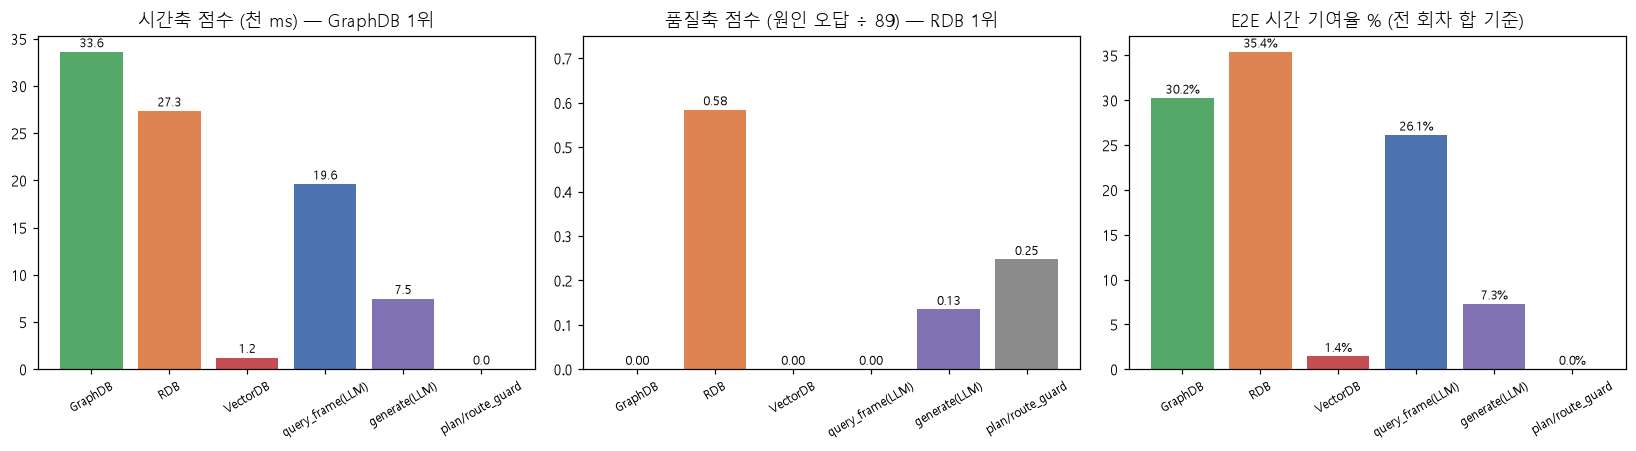

In [ ]:

# ▶ 계층 점수
# 표 3 — 계층별 시간축 점수(p95 기여 × 질의 비율) vs 품질축 점수(원인 오답 ÷ 89)
lay = pd.DataFrame(S["layers"]).set_index("layer")
display(lay[["mean", "p95", "share_pct", "share_q", "wrong", "time_score", "quality_score", "time_rank", "quality_rank"]]
        .rename(columns={"mean": "평균 기여 ms", "p95": "p95 기여 ms", "share_pct": "E2E 기여율 %", "share_q": "타는 질의 비율",
                         "wrong": "원인 오답 수", "time_score": "시간축 점수", "quality_score": "품질축 점수",
                         "time_rank": "시간 순위", "quality_rank": "품질 순위"})
        .style.format({"평균 기여 ms": "{:,.0f}", "p95 기여 ms": "{:,.0f}", "E2E 기여율 %": "{:.1f}", "타는 질의 비율": "{:.2f}",
                       "시간축 점수": "{:,.0f}", "품질축 점수": "{:.2f}", "시간 순위": "{:.0f}", "품질 순위": "{:.0f}"}, na_rep="-"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
order = ["GraphDB", "RDB", "VectorDB", "query_frame(LLM)", "generate(LLM)", "plan/route_guard"]
col = ["#55a868", "#dd8452", "#c44e52", "#4c72b0", "#8172b3", "#8c8c8c"]
ax = axes[0]; ax.bar(order, lay.loc[order, "time_score"] / 1000, color=col)
for i, v in enumerate(lay.loc[order, "time_score"] / 1000):
    ax.text(i, v + 0.5, f"{v:,.1f}", ha="center", fontsize=8)
ax.set_title("시간축 점수 (천 ms) — GraphDB 1위"); ax.tick_params(axis="x", rotation=30, labelsize=8)
ax = axes[1]; ax.bar(order, lay.loc[order, "quality_score"], color=col)
for i, v in enumerate(lay.loc[order, "quality_score"]):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_title("품질축 점수 (원인 오답 ÷ 89) — RDB 1위"); ax.tick_params(axis="x", rotation=30, labelsize=8); ax.set_ylim(0, 0.75)
ax = axes[2]; ax.bar(order, lay.loc[order, "share_pct"], color=col)
for i, v in enumerate(lay.loc[order, "share_pct"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=8)
ax.set_title("E2E 시간 기여율 % (전 회차 합 기준)"); ax.tick_params(axis="x", rotation=30, labelsize=8)
plt.tight_layout(); plt.show()

### 질의별 단계 누적 시간 (warm 중앙값, 1칸=1초)

| ID | frame | rdb | graph | vector | generate | E2E p50 s | 막대 (F=frame R=rdb G=graph V=vector A=generate) |
|---|---:|---:|---:|---:|---:|---:|---|
| Q1 | 9,159 | 12,875 | 0 | 1,222 | 2,734 | 24.7 | `FFFFFFFFFRRRRRRRRRRRRRVAAA` |
| Q2 | 6,782 | 10,723 | 0 | 0 | 3,442 | 21.0 | `FFFFFFFRRRRRRRRRRRAAA` |
| Q3 | 12,132 | 1,011 | 0 | 1,035 | 0 | 14.8 | `FFFFFFFFFFFFRV` |
| Q4 | 8,340 | 9,926 | 0 | 0 | 1,622 | 19.4 | `FFFFFFFFRRRRRRRRRRAA` |
| Q5 | 7,265 | 10,155 | 0 | 1,618 | 3,551 | 24.0 | `FFFFFFFRRRRRRRRRRVVAAAA` |
| Q6 | 6,958 | 11,531 | 0 | 0 | 0 | 20.4 | `FFFFFFFRRRRRRRRRRRR` |
| Q7 | 6,700 | 18,041 | 0 | 284 | 0 | 25.1 | `FFFFFFFRRRRRRRRRRRRRRRRRR` |
| Q8 | 11,103 | 11,748 | 0 | 0 | 3,837 | 26.7 | `FFFFFFFFFFFRRRRRRRRRRRRAAAA` |
| Q9 | 6,538 | 10,051 | 0 | 1,023 | 2,706 | 19.8 | `FFFFFFFRRRRRRRRRRVAAA` |
| Q10 | 13,655 | 14,729 | 107,584 | 1,146 | 3,550 | 140.8 | `FFFFFFFFFFFFFFRRRRRRRRRRRRRRRGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGVAAAA` |
| Q11 | 12,474 | 9,993 | 0 | 0 | 7,313 | 29.8 | `FFFFFFFFFFFFRRRRRRRRRRAAAAAAA` |
| Q12 | 13,555 | 10,743 | 0 | 0 | 0 | 24.5 | `FFFFFFFFFFFFFFRRRRRRRRRRR` |
| Q13 | 12,372 | 14,972 | 0 | 0 | 8,776 | 36.1 | `FFFFFFFFFFFFRRRRRRRRRRRRRRRAAAAAAAAA` |
| Q14 | 7,491 | 10,088 | 0 | 0 | 7,031 | 24.6 | `FFFFFFFRRRRRRRRRRAAAAAAA` |
| Q15 | 11,207 | 10,033 | 0 | 0 | 0 | 22.7 | `FFFFFFFFFFFRRRRRRRRRR` |
| Q16 | 7,897 | 13,568 | 0 | 1,735 | 7,047 | 30.3 | `FFFFFFFFRRRRRRRRRRRRRRVVAAAAAAA` |
| Q17 | 8,895 | 13,021 | 0 | 0 | 0 | 22.3 | `FFFFFFFFFRRRRRRRRRRRRR` |
| Q18 | 8,656 | 12,311 | 0 | 0 | 9,148 | 29.9 | `FFFFFFFFFRRRRRRRRRRRRAAAAAAAAA` |
| Q19 | 11,644 | 11,860 | 0 | 0 | 0 | 23.6 | `FFFFFFFFFFFFRRRRRRRRRRRR` |
| Q20 | 8,681 | 18,455 | 0 | 2,299 | 4,564 | 34.8 | `FFFFFFFFFRRRRRRRRRRRRRRRRRRVVAAAAA` |
| Q21 | 7,811 | 21,182 | 0 | 1,848 | 3,168 | 34.0 | `FFFFFFFFRRRRRRRRRRRRRRRRRRRRRVVAAA` |
| Q22 | 9,514 | 10,763 | 14,171 | 0 | 1,623 | 40.3 | `FFFFFFFFFFRRRRRRRRRRRGGGGGGGGGGGGGGAA` |
| Q23 | 20,780 | 27,265 | 91,743 | 0 | 7,644 | 146.0 | `FFFFFFFFFFFFFFFFFFFFFRRRRRRRRRRRRRRRRRRRRRRRRRRRGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGAAAAAAAA` |
| Q24 | 13,988 | 11,355 | 99 | 683 | 4,798 | 30.8 | `FFFFFFFFFFFFFFRRRRRRRRRRRVAAAAA` |
| Q25 | 8,941 | 10,124 | 0 | 258 | 0 | 19.5 | `FFFFFFFFFRRRRRRRRRR` |
| Q26 | 20,398 | 46,336 | 108,237 | 1,601 | 1,882 | 176.7 | `FFFFFFFFFFFFFFFFFFFFRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGVVAA` |
| Q27 | 16,561 | 23,106 | 54,412 | 1,595 | 4,976 | 96.8 | `FFFFFFFFFFFFFFFFFRRRRRRRRRRRRRRRRRRRRRRRGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGVVAAAAA` |
| Q28 | 13,625 | 21,363 | 610 | 1,188 | 3,569 | 42.0 | `FFFFFFFFFFFFFFRRRRRRRRRRRRRRRRRRRRRGVAAAA` |
| Q29 | 12,561 | 10,671 | 13,998 | 279 | 0 | 37.0 | `FFFFFFFFFFFFFRRRRRRRRRRRGGGGGGGGGGGGGG` |
| Q30 | 8,785 | 25,887 | 0 | 1,212 | 2,698 | 39.4 | `FFFFFFFFFRRRRRRRRRRRRRRRRRRRRRRRRRRVAAA` |
| Q31 | 9,223 | 1,686 | 0 | 0 | 0 | 11.1 | `FFFFFFFFFRR` |
| Q32 | 6,585 | 15,905 | 0 | 0 | 0 | 26.4 | `FFFFFFFRRRRRRRRRRRRRRRR` |
| Q33 | 6,710 | 8,151 | 0 | 254 | 0 | 14.9 | `FFFFFFFRRRRRRRR` |
| Q34 | 6,607 | 8,538 | 0 | 342 | 0 | 16.0 | `FFFFFFFRRRRRRRRR` |
| Q35 | 6,711 | 6,429 | 16,202 | 0 | 1,786 | 24.0 | `FFFFFFFRRRRRRGGGGGGGGGGGGGGGGAA` |

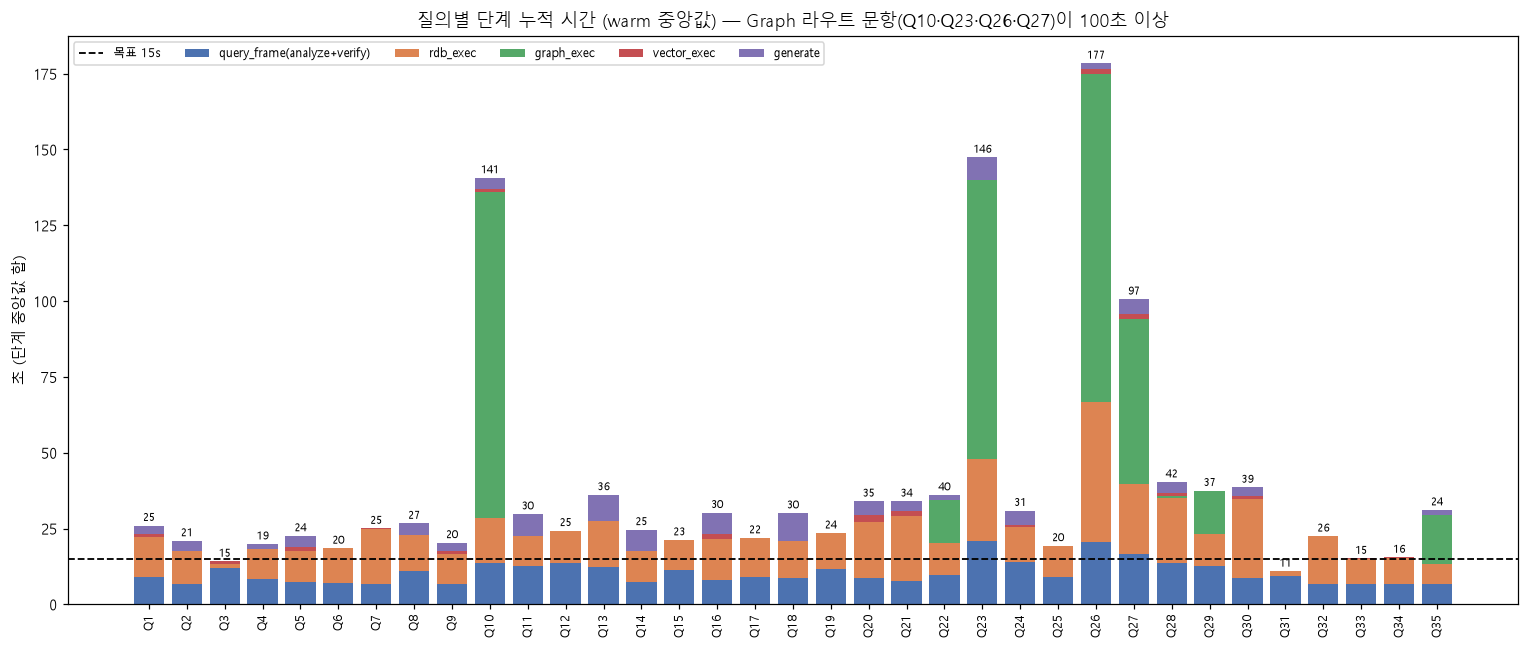

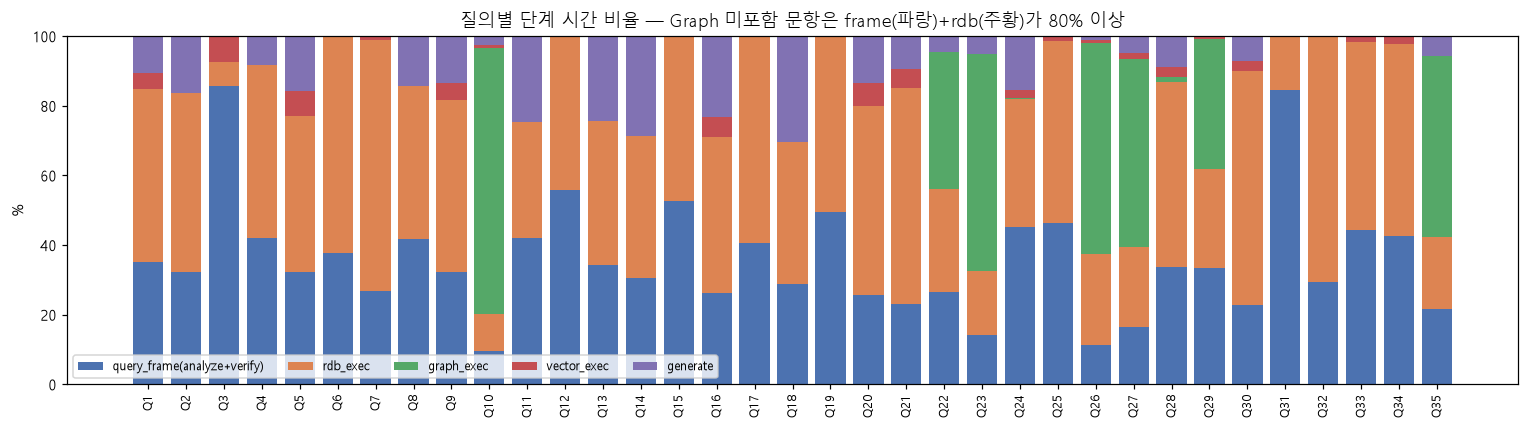

In [13]:
# ▶ 적층 막대
# 질의별 단계 누적 시간 (warm 중앙값) — ASCII 막대를 적층 막대로
import numpy as np
stages = ["frame", "rdb", "graph", "vector", "generate"]
st = Q[stages] / 1000
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(st))
for s in stages:
    ax.bar(st.index, st[s], bottom=bottom, color=STAGE_COLOR[s], label=STAGE_LABEL[s])
    bottom += st[s].values
ax.axhline(TARGET_MS / 1000, color="black", ls="--", lw=1.2, label="목표 15s")
for i, (qid, tot) in enumerate(zip(st.index, Q["e2e_p50"] / 1000)):
    ax.text(i, bottom[i] + 1.5, f"{tot:.0f}", ha="center", fontsize=7)
ax.set_ylabel("초 (단계 중앙값 합)"); ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.set_title("질의별 단계 누적 시간 (warm 중앙값) — Graph 라우트 문항(Q10·Q23·Q26·Q27)이 100초 이상")
ax.legend(ncol=6, fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()

# 같은 데이터를 100% 비율로 — 어느 단계가 각 문항 시간을 차지하는가
share = st.div(st.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(14, 4))
bottom = np.zeros(len(share))
for s in stages:
    ax.bar(share.index, share[s], bottom=bottom, color=STAGE_COLOR[s], label=STAGE_LABEL[s])
    bottom += share[s].values
ax.set_ylabel("%"); ax.set_ylim(0, 100); ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.set_title("질의별 단계 시간 비율 — Graph 미포함 문항은 frame(파랑)+rdb(주황)가 80% 이상")
ax.legend(ncol=6, fontsize=8, loc="lower left"); plt.tight_layout(); plt.show()

### 루브릭 유형별 오답률 (1칸=5%)

| 유형 | 오답률 % | 막대 |
|---|---:|---|
| 산출가능 | 78.0 | `████████████████` |
| 부분산출 | 100.0 | `████████████████████` |
| 외부데이터필요 | 66.7 | `█████████████` |
| 정의변경 | 100.0 | `████████████████████` |
| ABSTAIN | 86.7 | `█████████████████` |

원인 코드 A~F 정의(지시문) → 루브릭 코드 매핑: A 그래프 데이터 부재(RETRIEVAL_MISS·0바인딩, source=graph) / B 벡터 검색 실패(source=vector) / C RDB(FILTER_ERROR·QUERY_*·RETRIEVAL_MISS·STALE_DEFINITION) / D 계획·라우팅(ROUTING_MISS·PLAN_MISS, ABSTAIN 사유를 파이프라인이 산출하지 못한 경우) / E 생성(GENERATION_OMISSION·WRONG_VALUE·UNSUPPORTED_INFERENCE·UNGROUNDED_CLAIM·MISSING_EVIDENCE) / F 인프라(예외·타임아웃·429). 한 문항에 여러 코드가 있으면 가장 앞 단계(D > A/B/C > E)를 원인으로 삼았다.

오답 89회차의 원인 분포: C 52(58.4%) / D 22(24.7%) / E 12(13.5%) / F 3(3.4%) / A 0 / B 0. 실패 코드 빈도: GENERATION_OMISSION 54, RETRIEVAL_MISS 42, FILTER_ERROR 18, MISSING_EVIDENCE 13, ROUTING_MISS 12, STALE_DEFINITION 9, UNSUPPORTED_INFERENCE 6, QUERY_GENERATION_ERROR 5, QUERY_EXECUTION_ERROR 4, WRONG_VALUE 3, INFRA_EXCEPTION 3, UNGROUNDED_CLAIM 1.

대표 오답 패턴(수동 검토, 회차 간 동일 재현):
- 플래그 코드값 리터럴 불일치(Q12 `pd_sale_yn = '판매 중'` 실값 '1'/'0', Q19 `sale_yn = '판매 중'` 실값 '판매중') → 0행. FILTER_ERROR.
- 폐기 컬럼 사용(Q1·Q11·Q13 SQL에 `buyable_quantity`) → STALE_DEFINITION(Critical).
- 한글 별칭에 공백(`AS 정식 상품명`)·존재하지 않는 enriched 테이블 조인 → SyntaxError 3회 재시도 후 실패(Q6·Q7·Q23·Q30).
- 발행사 필터 누락(Q26·Q27 `WHERE std_pd_mcls_nm='회사채'`만) → 무관한 채권을 SK하이닉스/LG 발행 채권으로 제시(UNSUPPORTED_INFERENCE).
- 상품군 오분류(Q7 BND→펀드, Q15 국내ETF→해외ETF, Q29 VOO/IVV/SPY→국내ETF) → ROUTING_MISS(D).
- ABSTAIN 5문항 중 사유를 답변에 쓴 것은 Q34(2027 미래값) 1회차, Q32 1회차뿐. Q31은 RDB 노드가 "AAAA는 crd_grd 유효값 아님"을 skipped_reason으로 산출했으나 generate가 "답변할 수 없습니다"만 출력(E). Q35는 채권 테이블 0건 → "회사채 정보가 없습니다"로 루브릭 §12의 오답 패턴 그대로(D).
- 목록형 답변이 max_tokens 2048을 넘어 구조화 출력 파싱 실패(Q11 r4·Q13 r3·Q14 r4, LengthFinishReasonError) → 답변 없음(F). 30s timeout 조건의 사전 실행에서는 같은 문항이 APITimeoutError였다.

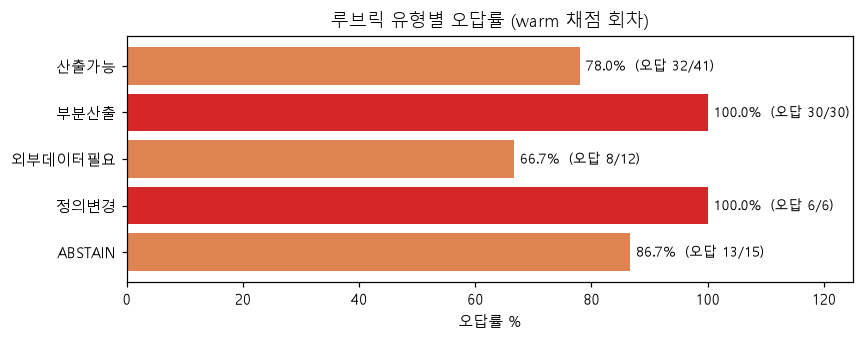

In [14]:
# ▶ 유형별 오답률
# 루브릭 유형별 오답률
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(TYPE_ORDER, type_stats["오답률 %"], color=["#d62728" if v >= 90 else "#dd8452" for v in type_stats["오답률 %"]])
for b, (v, p, n) in zip(bars, zip(type_stats["오답률 %"], type_stats["정답회차"], type_stats["채점회차"])):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.1f}%  (오답 {n-p}/{n})", va="center", fontsize=9)
ax.set_xlim(0, 125); ax.invert_yaxis(); ax.set_xlabel("오답률 %"); ax.set_title("루브릭 유형별 오답률 (warm 채점 회차)")
plt.tight_layout(); plt.show()

## 5. 병목 판정과 액션 아이템

### 5.1 계층 우선순위 (decision_rules 적용)

시간축 점수 = p95 기여 ms × 그 계층을 타는 질의 비율, 품질축 점수 = 원인 오답 수 ÷ 전체 오답(89).

| 계층 | p95 기여 ms | 질의 비율 | 시간축 점수 | 원인 오답 | 품질축 점수 | 시간 순위 | 품질 순위 |
|---|---:|---:|---:|---:|---:|---:|---:|
| GraphDB | 117,593 | 0.29 | 33,598 | 0 | 0.00 | 1 | 2 |
| RDB | 27,333 | 1.00 | 27,333 | 52 | 0.58 | 2 | 1 |
| VectorDB | 2,280 | 0.54 | 1,237 | 0 | 0.00 | 3 | 3 |

시간축 1위와 품질축 1위가 다르므로 두 시나리오를 둔다.

- 속도 우선안(1순위 GraphDB): resolve_frame_seed가 이름을 클래스(ETF/PublicFund/Bond/Company…)별로 순차 SPARQL 조회하며 조회당 p95 14.4s가 걸린다(표 4.1). 정확 일치 라벨 인덱스(rdfs:label → URI 사전, 스토어 오픈 시 1회 구축)로 바꾸면 조회 의미가 같아 품질 영향이 없고, Graph 포함 28회차의 p95를 176.7s에서 70.3s(추정, seed 500ms 가정)로 줄인다. 근거 질의 ID: Q10(seed 2회 107.6s), Q23(91.7s), Q26(108.2s), Q27(54.4s).
- 품질 우선안(1순위 RDB): 오답의 58.4%가 SQL 생성 단계다. 코드값 사전(플래그·판매상태) 주입, 별칭 공백 금지·테이블 화이트리스트, 폐기 컬럼 차단, 상품명·발행사 필터 필수화, sort.limit 오적용 방지가 대상이다. 근거 질의 ID: Q12·Q19(FILTER_ERROR), Q1·Q11·Q13(STALE_DEFINITION), Q6·Q7·Q30(SyntaxError), Q26·Q27(발행사 필터 누락), Q10(LIMIT 1). 같은 조치가 fix 재시도 49회(161s)도 줄이므로 속도에도 이롭다.

두 안은 배타적이지 않다. 단일 우선순위를 묻는 P0(15초)에는 GraphDB가 1순위이고, P1(품질)을 함께 만족하려면 RDB SQL 생성 보정을 같은 스프린트에 넣는다.

### 5.2 Action Items

1) LangGraph 파이프라인 디벨롭 필요 여부
- [결론 No]
- [근거 수치] (a) 서로 독립인데 순차 실행된 단계(같은 rdb_search 호출 안의 도메인 단계, topic별 임베딩)의 합은 p95 회차 기준 E2E의 14.0%(11,251ms), 20% 이상은 101회차 중 5회차뿐. (b) 재시도·폴백 396,968ms = 9.8%. (c) 원인 D 22/89 = 24.7%.
- [근거 질의 ID] (a) 초과 5회차는 Q21·Q23·Q26·Q27·Q30(다중 도메인 RDB). (c) Q7·Q15·Q16·Q29·Q32·Q33·Q35.
- [시간을 실제로 쓰는 지점] ① LLM 호출이 E2E의 68.4%(문항당 p50 6회, 최대 16회): query_frame 2회 9.1s, RDB 3~4회 11.4s, generate 1회 2.0s. ② Graph 엔티티 해소 SPARQL 순차 조회(노드 내부, 관계당 p50 15.1s). 후자를 "독립 단계 병렬화" 대상으로 넓게 읽으면 p95 회차의 41.8%가 되지만, 조회당 3~9s인 스캔을 병렬로 돌리는 것보다 인덱스로 없애는 것이 맞으므로 LangGraph 재배선 사유로 보지 않는다.
- [예상 단축] 해당 없음(No). 참고로 A5(도메인 단계 병렬)만 적용하면 p95 회차 기준 11.0s, 평균 1.3s 단축(추정).
- [작업 규모] 해당 없음.

2) 온톨로지 DB / VectorDB 추가 데이터 필요 여부
- 온톨로지 DB: [결론 No] · [근거 수치] 원인 A 0/89 = 0%(임계 30%). Graph orchestrator 62회 중 abstain_entity_not_found 33회·abstain_evidence_missing 14회가 있었으나 해당 Claim은 골든에서 external_required(편입·자회사 관계)라 정상 abstain으로 채점됐고, 오답의 원인이 된 available Graph Claim은 없었다. · [근거 질의 ID] Q22·Q24·Q28(정상 external gap), Q10(우리반도체BIG2플러스 엔티티 미해소이나 RDB가 답을 냄). · [예상 개선폭] 0(현재 오답과 무관). · [작업 규모] 해당 없음.
- VectorDB: [결론 No] · [근거 수치] 원인 B 0/89 = 0%. Vector 단계 52회 상태: ok 16, no_product_match 15, no_hit 8, topic_not_covered 7, no_document 5, low_confidence 1. no_product_match 15건은 데이터 부족이 아니라 product_master 완전일치 실패(인덱스·엔티티 해소 문제, 예: Q6 VOO, Q7 BND, Q29 VOO/IVV/SPY)이고, no_document 5건이 데이터 부족(Q10·Q24)이다. 두 종류 모두 오답의 1차 원인이 아니었다. · [근거 질의 ID] Q6·Q7·Q29(no_product_match), Q10·Q24(no_document), Q16·Q20·Q28(ok). · [예상 개선폭] 0. · [작업 규모] 해당 없음.

3) 15초 달성 로드맵 (warm ok 101회차에 조치별 예상 단축을 계측값에서 차감해 p95를 재계산한 추정치. roadmap.py)

| 순서 | 조치 | 계층 | 단축 근거(실측 구간) | 단축 평균 ms | p95 회차 단축 ms | 적용 후 p95 ms | >15s 회차 | 품질 영향 | 규모 |
|---:|---|---|---|---:|---:|---:|---:|---|---|
| 0 | 현재 | - | - | - | - | 144,006 | 94/101 | - | - |
| A1 | Graph 엔티티 해소 exact-label 인덱스 | GraphDB | resolve_frame_seed 49회 p50 15,101 → 500 가정 | 10,873 | 80,454 | 70,301 | 91 | 없음(동일 결과) | M |
| A2 | verify_intent 제거 | query_frame | verify 노드 p50 5,029 | 5,697 | 10,887 | 58,975 | 80 | 미측정(35/101회차에서 intent 수정) — A/B 전 권고 보류 | S |
| A3 | SQL draft·concept_fallback LLM 제거(카탈로그 보강 + 단일 SQL 호출) | RDB | draft p50 5,515 + concept 1,983 | 8,801 | 16,388 | 35,820 | 28 | 미측정(SQL 품질 재측정 필요) | M |
| A4 | SQL fix 재시도 제거(코드값 사전·별칭 규칙) | RDB | fix_sql 49회 p50 2,997 | 1,597 | 8,820 | 24,576 | 25 | 개선(품질 우선안과 동일 조치) | M |
| A5 | RDB 도메인 단계 병렬 | RDB | 같은 노드 안 순차 단계 합-최댓값 | 1,303 | 11,027 | 20,158 | 20 | 없음 | S |
| A6 | generate 미리보기 축소·답변 형식 고정(4s 상한) | generate | generate p95 9,355 | 893 | 5,148 | 17,595 | 12 | 개선(길이 초과 예외 3회 제거) | S |

- 합산: A1~A6 전부 적용 시 p95 17.6s(추정)로 목표 15.0s에 **2.6s 부족**, 12/101회차(Q20·Q23·Q24·Q27·Q28)가 남는다. 남는 회차는 Graph 3~5관계 + RDB 2~3도메인 + Vector가 겹치는 문항으로, analyze_intent 한 번(p95 8.7s)만으로 Query Frame 5s 목표도 넘는다.
- A2를 빼면(품질 미검증) p95 26.6s로 부족분 11.6s. A1만 적용하면 p95 70.3s.
- 부족분 2.6s를 덮으려면 추가로 analyze_intent 프롬프트 축소(prompt 3,940 tok → 절반 가정 시 2s 내외, 추정)와 Graph 관계 체인의 seed 공유(같은 이름을 관계마다 다시 해소하지 않기)가 필요하며, 이 둘은 이번 측정에 근거가 없어 수치로 넣지 않았다.

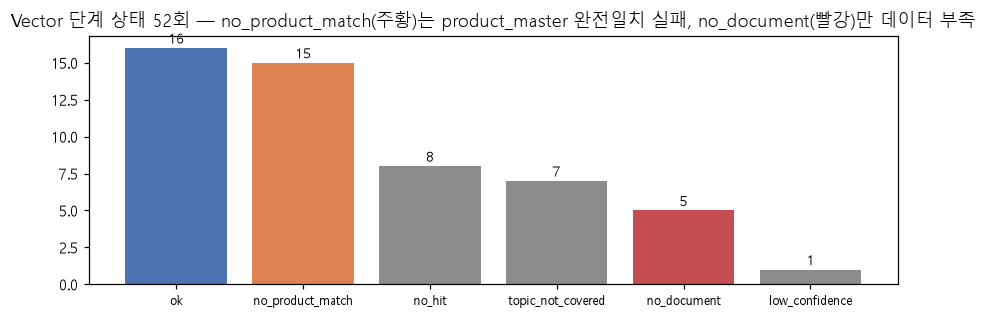

Graph 단계 상태: {'chained': 15, 'abstain_entity_not_found': 37, 'ok': 9, 'abstain_evidence_missing': 14, 'abstain_invalid_graph_plan': 2}


In [15]:
# ▶ Vector·Graph 단계 상태
# 2) 근거 — Vector 단계 상태 분포 (warm ok 회차 step_results, engine=vector)
vs = Counter(r.get("status") for t in warm_ok for r in (t.get("step_results") or {}).values()
             if isinstance(r, dict) and r.get("engine") == "vector")
vs = pd.Series(vs).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(vs.index, vs.values, color=["#4c72b0" if k == "ok" else "#dd8452" if k == "no_product_match" else "#c44e52" if k == "no_document" else "#8c8c8c" for k in vs.index])
for i, v in enumerate(vs.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=9)
ax.set_title(f"Vector 단계 상태 {vs.sum()}회 — no_product_match(주황)는 product_master 완전일치 실패, no_document(빨강)만 데이터 부족")
ax.tick_params(axis="x", labelsize=8); plt.tight_layout(); plt.show()

# Graph orchestrator 상태(warm ok 회차)
gs = Counter(r.get("status") for t in warm_ok for r in (t.get("step_results") or {}).values()
             if isinstance(r, dict) and r.get("engine") == "graph")
print("Graph 단계 상태:", dict(gs))

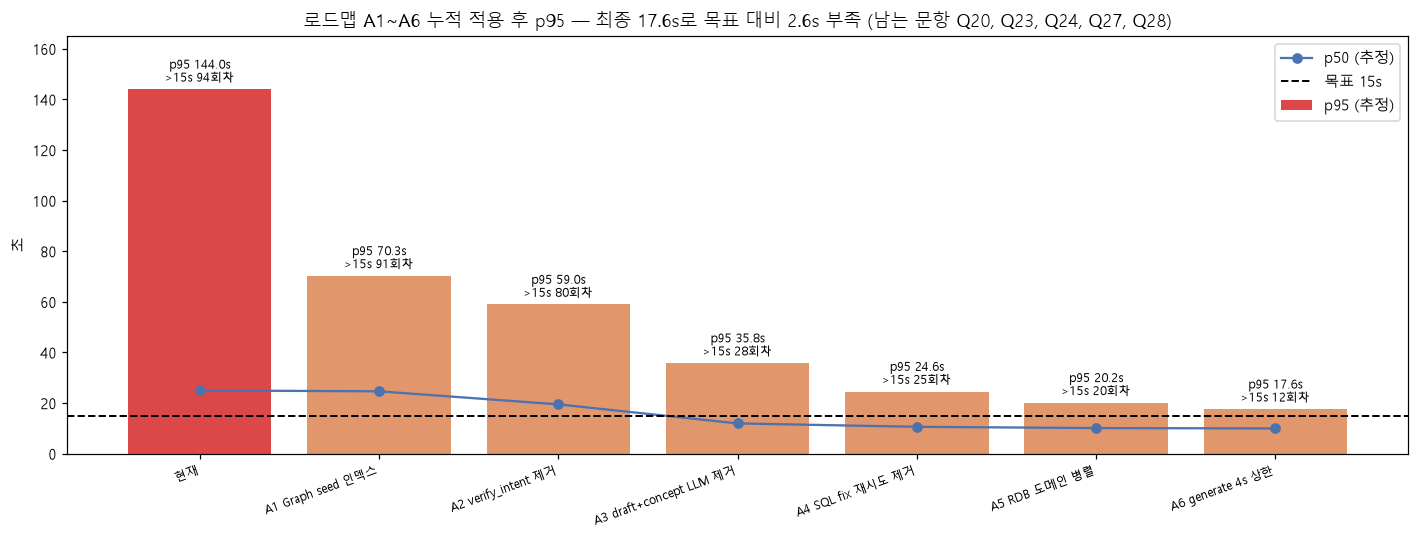

조치,단축 평균 ms,p95 회차 단축 ms,적용 후 p50 ms,적용 후 p95 ms,적용 후 max ms,>15s 회차
A1 Graph seed 인덱스,"10,873","80,454","24,658","70,301","96,292",91
A2 verify_intent 제거,"5,697","10,887","19,499","58,975","84,931",80
A3 draft+concept LLM 제거,"8,801","16,388","11,971","35,820","73,020",28
A4 SQL fix 재시도 제거,"1,597","8,820","10,626","24,576","63,406",25
A5 RDB 도메인 병렬,"1,303","11,027","10,126","20,158","60,701",20
A6 generate 4s 상한,893,"5,148","9,984","17,595","55,667",12


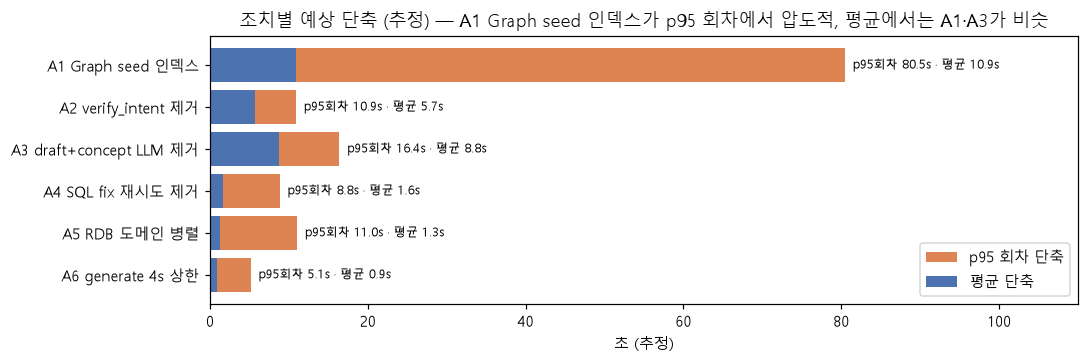

In [16]:
# ▶ 로드맵
# 3) 15초 로드맵 — 조치 누적 적용 후 p95 (추정, roadmap.json)
steps = ROAD["steps"]
labels = ["현재"] + [s["action"] for s in steps]
p95s = [ROAD["current"]["p95"]] + [s["p95_after"] for s in steps]
p50s = [ROAD["current"]["p50"]] + [s["p50_after"] for s in steps]
over = [S["warm"]["over_15s_runs"]] + [s["over15"] for s in steps]

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(labels))
ax.bar(x, [v / 1000 for v in p95s], color=["#d62728"] + ["#dd8452"] * len(steps), alpha=0.85, label="p95 (추정)")
ax.plot(list(x), [v / 1000 for v in p50s], "o-", color="#4c72b0", label="p50 (추정)")
ax.axhline(15, color="black", ls="--", lw=1.3, label="목표 15s")
for i, (p95, p50, o) in enumerate(zip(p95s, p50s, over)):
    ax.text(i, p95 / 1000 + 3, f"p95 {p95/1000:.1f}s\n>15s {o}회차", ha="center", fontsize=8)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("초"); ax.set_ylim(0, 165)
ax.set_title(f"로드맵 A1~A6 누적 적용 후 p95 — 최종 {p95s[-1]/1000:.1f}s로 목표 대비 {p95s[-1]/1000-15:.1f}s 부족 (남는 문항 {', '.join(ROAD['remaining_over15'])})")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

rm = pd.DataFrame([{"조치": s["action"], "단축 평균 ms": s["saving_mean"], "p95 회차 단축 ms": s["saving_p95_run"],
                    "적용 후 p50 ms": s["p50_after"], "적용 후 p95 ms": s["p95_after"], "적용 후 max ms": s["max_after"], ">15s 회차": s["over15"]} for s in steps])
display(rm.style.format({c: "{:,.0f}" for c in rm.columns if c.endswith("ms")}).hide(axis="index"))

# 조치별 단축량(막대) — 어디서 얼마나 빠지는가
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.barh([s["action"] for s in steps], [s["saving_p95_run"] / 1000 for s in steps], color="#dd8452", label="p95 회차 단축")
ax.barh([s["action"] for s in steps], [s["saving_mean"] / 1000 for s in steps], color="#4c72b0", label="평균 단축")
for i, s in enumerate(steps):
    ax.text(s["saving_p95_run"] / 1000 + 1, i, f"p95회차 {s['saving_p95_run']/1000:.1f}s · 평균 {s['saving_mean']/1000:.1f}s", va="center", fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("초 (추정)"); ax.set_xlim(0, 110); ax.legend(loc="lower right")
ax.set_title("조치별 예상 단축 (추정) — A1 Graph seed 인덱스가 p95 회차에서 압도적, 평균에서는 A1·A3가 비슷")
plt.tight_layout(); plt.show()

## 6. 실패·결함 기록

| 결함 | 원인 | 조치 |
|---|---|---|
| 첫 본 실행이 Q3에서 429(remaining 43) | 요청 한도가 아닌 토큰 한도 60k/min 소진. 호출당 prompt+max_tokens 예약(추정) | 하네스에 토큰 잔량 가드(30k 미만 대기)와 새 창 1회 재실행 추가. 루브릭 §13의 "8.6 질의/분"은 max_tokens=1 실측이라 실제 파이프라인엔 적용되지 않음 |
| Q11·Q14가 30s timeout(사전 실행) | 목록형 답변 생성이 30s 초과 | 사용자 요청으로 _llm_answer timeout 90s로 변경 후 재측정. 같은 문항이 이번엔 max_tokens 2048 초과 예외로 실패 — 원인은 timeout이 아니라 답변 길이 |
| pkill -f 가 셸 자신을 종료 | 패턴이 실행 명령줄과 일치 | 정규식 `python[.]exe` 패턴으로 회피 |
| 결정론 채점기 오탐 5종 | 필드 검사가 plan 텍스트까지 봄, external gap이 "없"만으로 인정, think_trace를 답변으로 취급 등 | SQL 텍스트·행 키로 한정, external은 구체 gap 토큰 요구, answer 본문만 채점, 수동 오버라이드 9건(조건부) 추가 |
| Graph 노드가 웨이브마다 재호출돼 노드 시간이 분할 기록 | 체인 관계가 2개 이상이면 dispatch가 graph_search를 다시 스케줄 | 회차 내 노드 시간을 합산해 집계 |

## 7. 지표 정의

| 지표 | 정의 | 단위 |
|---|---|---|
| E2E | app.stream() 첫 호출부터 generate_answer 갱신 수신까지 벽시계 시간 | ms |
| 단계 ms | 노드 함수 진입~반환. 같은 노드가 여러 웨이브에 걸치면 합산 | ms |
| p95 | nearest-rank 백분위(문항당 warm 3회차면 최댓값) | ms |
| 시간축 점수 | 계층 p95 기여 ms × 그 계층 단계를 실행한 질의 비율 | ms |
| 품질축 점수 | 그 계층이 1차 원인인 오답 회차 ÷ 오답 회차 전체 | 비율 |
| 정답 | 루브릭 §11: CRITICAL(UNSUPPORTED_INFERENCE·UNGROUNDED_CLAIM·MISSED_ABSTAIN·STALE_DEFINITION) 0건 AND ERROR 0건 | O/△/X |
| 조용한 실패 | rows=0·0바인딩·abstain_* 상태·skipped_reason. 성공으로 세지 않음 | 건 |

## 8. 실행 제약·미측정 항목

- 미측정: verify_intent 제거·SQL draft 통합의 정답률 영향(파이프라인 로직 변경 금지 제약으로 A/B 미실행). 로드맵 A2·A3의 품질 열은 그래서 "미측정"이다.
- 미측정: 문항당 1회차만 있는 cold의 p95(35문항 각 1회라 문항 단위 p95 불가, 전체 35회차 p95만 산출).
- 미측정: CLOVA 토큰 예약 방식(prompt+max_tokens)은 헤더 관측으로 추정한 값이며 공식 문서로 확인하지 않았다.
- 미측정: 루브릭 §11-B LLM-as-a-Judge. 결정론 판정 + 사람 검토(1·2회차 전 문항, 3·4회차는 판정이 바뀐 문항)로 대체했다.
- 제약: 답변 생성 timeout이 측정 도중 30s→90s로 바뀌어 30s 조건 16회차(traces_aborted_timeout30.jsonl)는 본 집계에서 제외했다.
- 제약: p95는 문항당 3회차라 최댓값과 같다. 표 1의 p95 열은 그 의미로 읽어야 한다.

## 부록

### A. 미측정 항목과 사유
§8 참조.

### B. 측정 한계
- 답변 텍스트 채점은 토큰 일치 기반이라 수치 표기 차이를 완전히 흡수하지 못한다. 1·2회차는 35문항 전부 사람이 대조했고 3·4회차는 판정이 바뀐 8문항만 대조했다.
- 계층 시간은 노드 단위다. graph_search 안의 LLM plan 생성(fast-path 적용으로 0회)과 SPARQL 실행(p50 17ms)은 seed 해소와 분리해 표 4.1에 적었다.
- 429 재실행 회차는 같은 창을 피했으므로 지연 통계에 포함했다. 파이프라인 내부 429(Q21 r3)는 제외했다.

severity          CRITICAL                                               ERROR                                                                                                                \
diagnosis STALE_DEFINITION UNGROUNDED_CLAIM UNSUPPORTED_INFERENCE FILTER_ERROR GENERATION_OMISSION MISSING_EVIDENCE QUERY_EXECUTION_ERROR QUERY_GENERATION_ERROR RETRIEVAL_MISS ROUTING_MISS   
type                                                                                                                                                                                           
산출가능                     0                0                     0           11                  55                0                    14                     15             93            6   
부분산출                     3                0                     9            3                  29                0                     9                      0             50            6   
외부데이터필요                  0                1                     2            4                  14                0                     0                      0              0            0   
정의변경                     6                0                     0            0                   5                0                     0                      0              3            0   
ABSTAIN                  0                0                     0            0                   0               13                     0                      0              0            0   

severity                          INFO                                                                                                        
diagnosis WRONG_VALUE EXPECTED_ABSTAIN EXTERNAL_DATA_REQUIRED EXTERNAL_EVIDENCE_PRESENT_OR_SCHEMA_CHECK_NEEDED PARTIAL_GAP_ACKNOWLEDGED PASS  
type                                                                                                                                          
산출가능                0                0                      0                                                0                        0  114  
부분산출                3                0                     12                                                6                        3   57  
외부데이터필요             0                0                     17                                               11                        5    4  
정의변경                0                0                      0                                                0                        0   16  
ABSTAIN             0                2                      0                                                0                        0    0

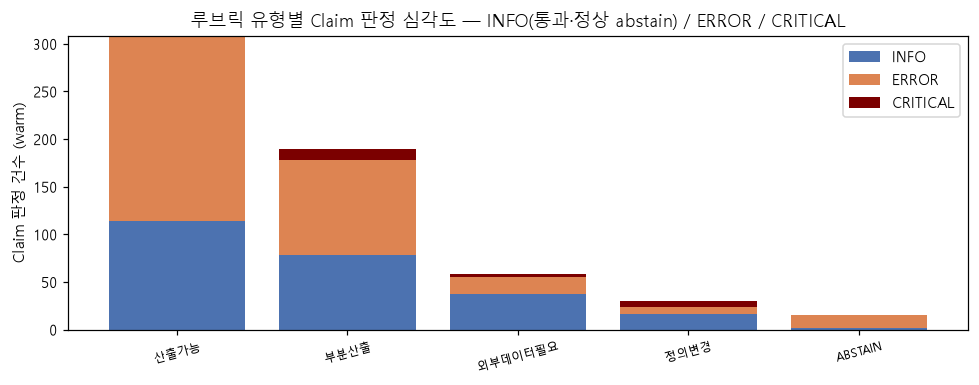

In [17]:
# ▶ Claim 심각도 분포
# 부록 — Claim 단위 진단 분포 (182 Claim × warm 회차) : 판정이 어디에서 갈리는가
cl = pd.DataFrame([c | {"round": e["round"], "type": Q.loc[e["question_id"], "type"]}
                   for e in (json.loads(l) for l in open(LAT / "per_run_eval.jsonl", encoding="utf-8"))
                   if e["round"] >= 2 for c in e["claim_results"]])
piv = pd.crosstab(cl["type"], [cl["severity"], cl["diagnosis"]]).reindex(TYPE_ORDER)
display(piv)

sev = pd.crosstab(cl["type"], cl["severity"]).reindex(index=TYPE_ORDER, columns=["INFO", "ERROR", "CRITICAL"], fill_value=0)
fig, ax = plt.subplots(figsize=(9, 3.6))
import numpy as np
bottom = np.zeros(len(TYPE_ORDER))
for sv, colr in [("INFO", "#4c72b0"), ("ERROR", "#dd8452"), ("CRITICAL", "#7b0000")]:
    ax.bar(TYPE_ORDER, sev[sv], bottom=bottom, color=colr, label=sv)
    bottom += sev[sv].values
ax.set_ylabel("Claim 판정 건수 (warm)"); ax.tick_params(axis="x", labelsize=8, rotation=15); ax.legend()
ax.set_title("루브릭 유형별 Claim 판정 심각도 — INFO(통과·정상 abstain) / ERROR / CRITICAL")
plt.tight_layout(); plt.show()

### C. 재현 방법

```bash
# repo 루트, Windows conda mirea python
python test/pipline-test/latency/run_latency.py --rounds 4 --out test/pipline-test/latency/traces_full.jsonl
python test/pipline-test/latency/build_golden_eval.py      # golden_eval.jsonl (182 claims)
python test/pipline-test/latency/analyze.py --warm-from 2  # analysis_summary.json / analysis_tables.md / per_run_eval.jsonl
python test/pipline-test/latency/roadmap.py                 # roadmap.json
python test/pipline-test/latency/review_dump.py --round 2 > review_round2.md
```

- 시드: LLM temperature 0, 문항 순서 CSV id 오름차순, 회차 내 순차. 무작위 시드 없음(HCX 출력은 temperature 0에서도 회차 간 차이가 있어 표 1의 정답 열에 회차 수를 병기했다).
- 산출물: traces_full.jsonl(140행), per_run_eval.jsonl, analysis_summary.json, analysis_tables.md, roadmap.json, manual_overrides.json, review_round{1..4}.md.

## 최종 판정

FAIL — warm p95 144.0s로 목표 15.0s에 129.0s 부족하고 정답률 14.4%다. 단, 이 판정은 "GraphDB나 VectorDB에 데이터를 더 넣어야 한다"를 의미하지 않는다(원인 A·B 0건). 느린 것은 Graph 엔티티 해소 방식과 LLM 호출 수이고, 틀린 것은 RDB SQL 생성이다.

## self_check

1. 표 1 단계 합 vs E2E ±10%: 101/101 회차 통과(노드 구간 합집합 기준). 통과.
2. 결론 문장의 수치 인용: Digest 8문장 전부 수치 포함. 통과.
3. 액션 아이템 1) No, 2) 온톨로지 No / VectorDB No 명시. 통과.
4. 미배선 라우트 없음 — 측정 계층만 순위. 통과.
5. 예상 단축 합이 격차를 덮는가: 아니다. A1~A6 후 p95 17.6s로 2.6s 부족, A2 제외 시 11.6s 부족을 명시. 통과(부족분 기재).
6. 0행·0바인딩·ABSTAIN·429를 성공으로 집계하지 않음: 0행은 RETRIEVAL_MISS/FILTER_ERROR, graph abstain은 golden availability로 판정, 429는 분모 제외. 통과.